# ¿Cuál es la mejor tarifa?

El propósito del proyecto es analizar el comportamiento de los clientes y determinar qué tarifa de prepago genera más ingresos. Para esto, se planea realizar las siguientes acciones:
1. Cargar los datos y realizar una inspección inicial para entender su estructura y contenido.
2. Realizar un análisis exploratorio de los datos para identificar patrones, tendencias y posibles problemas con los datos.
3. Calcular los ingresos generados por cada tarifa de prepago y compararlos por medio de prueba de hipótesis para determinar cuál es la más rentable.
4. Realizar visualizaciones para apoyar los hallazgos y comunicar los resultados de manera efectiva.
5. Concluir con recomendaciones basadas en el análisis realizado.

<b> NOTA IMPORTANTE: </b>:

Las compañias de telefonía suelen manejar ciclos de pago mensuales pero con días diferentes del mes en cada usuario. Al ser planes usualmente son formato prepago, es decir, se cobra el primer mes para activar, y los cargos adicionales y el próximo mes se cobran al finalizar el ciclo de pago. Estos planes suelen comportarse como un crédito con fechas de corte y de pago. Considerando esto, el análisis podría volverse un poco más complejo pero al no ser específicada esta característica en el proyecto, se asumirá que el ciclo de pago es mensual y que se cobra al finalizar cada mes y se reiniciará cada primero del mes para todos los usuarios. Esto simplificará el análisis y permitirá enfocarse en la comparación de las tarifas sin complicaciones adicionales relacionadas con los ciclos de pago específicos de cada usuario.

## Inicialización

In [1]:
# Cargar todas las librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("Librerías cargadas correctamente")

Librerías cargadas correctamente


## Cargar datos

In [2]:
# Carga los archivos de datos en diferentes DataFrames
llamadas = pd.read_csv('datasets/megaline_calls.csv')
internet = pd.read_csv('datasets/megaline_internet.csv')
mensajes = pd.read_csv('datasets/megaline_messages.csv')
tarifas = pd.read_csv('datasets/megaline_plans.csv')
usuarios = pd.read_csv('datasets/megaline_users.csv')

## Preparar los datos

## Tarifas

In [3]:
# Imprime la información general/resumida sobre el DataFrame de las tarifas
tarifas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 260.0+ bytes


In [4]:
# Imprime una muestra de los datos para las tarifas
tarifas.head()

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


Después de usar <code>tarifas.info()</code> podemos ver que el data frame consiste de 8  columnas, cada una con 2 entradas. 
Las columnas son: 
<ol>
    <li> <i>messages_included</i>: número de mensajes incluidos en el plan. </li>
    <li> <i>mb_per_month_included</i>: cantidad de megabytes incluidos por mes. </li>
    <li> <i>minutes_included</i>: minutos incluidos en el plan, al mes. </li>
    <li> <i>uds_montly_pay</i>: pago mensual del plan en dolares estadounidenses. </li>
    <li> <i>uds_per_gb</i>: costo por gigabyte adicional al exceder el límite del plan. </li>
    <li> <i>uds_per_message</i>: costo por mensaje adicional tras exceder el límite del plan. </li>
    <li> <i>uds_per_minute</i>: costo por minuto adicional tras exceder el límite del plan. </li>
    <li> <i>plan_name</i>: nombre del plan. </li>
</ol>

No hay datos inesperados o inconsistentes, por ello no se modificarán los datos de este data frame ni se agregarán nuevas columnas.

## Usuarios/as

In [5]:
# Imprime la información general/resumida sobre el DataFrame de usuarios
usuarios.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [6]:
# Imprime una muestra de datos para usuarios
usuarios.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN


Aquí podemos ver la tabla asociada a los usuarios, <i>users</i>. Esta tabla tiene 8 columnas, cada una con 500 entradas. Las columnas son:

<ol>
    <li> <i>user_id</i>: identificador único del usuario. </li>
    <li> <i>first_name</i>: nombre del usuario. </li>
    <li> <i>last_name</i>: apellido del usuario. </li>
    <li> <i>age</i>: edad del usuario (años). </li>
    <li> <i>city</i>: ciudad de residencia del usuario. </li>
    <li> <i>reg_date</i>: fecha de registro del usuario (aaaa, mm, dd). </li>
    <li> <i>plan</i>: plan contratado por el usuario. </li>
    <li> <i>churn_date</i>: la fecha en la que el usuario dejó de usar el servicio (si el valor es ausente, la tarifa se estaba usando cuando fue extraída esta base de datos).</li>
</ol>

Aquí podemos encontrar algunas inconsistencias.

1. El <i>tipo de dato</i> de <i>user_id</i> es entero, pero es un valor de identificación, será necesario convertirlo a cadena de texto.
2. El <i>tipo de dato</i> de <i>reg_date</i> y <i>churn_date</i> es cadena de texto, pero es una fecha, será necesario convertirlo a formato fecha.

Otras observaciones:
1. Se buscará por duplicados.
2. Aunque exiten valores nulos en la columna de <i>churn date</i> se espera la existencai de estos porque indican que el usuario sigue usando el servicio, por lo que no se eliminarán ni se imputarán estos valores.

### Corregir los datos

In [7]:
# Búsqueda de duplicados
usuarios_duplicados = usuarios.duplicated().sum()
print(f"Número de filas duplicadas en el DataFrame de usuarios: {usuarios_duplicados}")

Número de filas duplicadas en el DataFrame de usuarios: 0


In [8]:
# Conversión del tipo de dato de user_id a string
usuarios['user_id'] = usuarios['user_id'].astype(str)

# Conversión del tipo de dato de la columna 'reg_date' a formato datetime
usuarios['reg_date'] = pd.to_datetime(usuarios['reg_date'], format='%Y-%m-%d')

# Conversión del tipo de dato de la columna 'churn_date' a formato datetime
usuarios['churn_date'] = pd.to_datetime(usuarios['churn_date'], format='%Y-%m-%d')

In [9]:

print("Tipo de datos de usuarios después de la conversión:")
print(usuarios.dtypes)

print("\nPrimeras filas del DataFrame de usuarios después de la conversión:")
usuarios.head()

Tipo de datos de usuarios después de la conversión:
user_id               object
first_name            object
last_name             object
age                    int64
city                  object
reg_date      datetime64[ns]
plan                  object
churn_date    datetime64[ns]
dtype: object

Primeras filas del DataFrame de usuarios después de la conversión:


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaT
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaT
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaT
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaT


### Enriquecer los datos

In [10]:
# Columna nueva para contar el tiempo de registro, en años, desde la fecha de registro hasta el día de hoy.
usuarios['años_registro'] = (pd.to_datetime('today') - usuarios['reg_date']).dt.days / 365

print("\nPrimeras filas del DataFrame de usuarios después de agregar la columna 'años_registro':")  
usuarios.head()


Primeras filas del DataFrame de usuarios después de agregar la columna 'años_registro':


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,años_registro
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaT,7.271233
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT,7.635616
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaT,7.446575
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaT,8.175342
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaT,7.860274


## Llamadas

In [11]:
# Imprime la información general/resumida sobre el DataFrame de las llamadas
llamadas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [12]:
# Imprime una muestra de datos para las llamadas
llamadas.head()

,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22


In [13]:
llamadas.describe()

,user_id,duration
count,137735.000000,137735.000000
mean,1247.658046,6.745927
std,139.416268,5.839241
min,1000.000000,0.000000
25%,1128.000000,1.290000
50%,1247.000000,5.980000
75%,1365.000000,10.690000
max,1499.000000,37.600000


En esta tabla tenemos los datos de las llamadas realizadas por los usuarios. La tabla contiene 4 columnas, cada una con 137 735 entradas. Las columnas son:
<ol>
    <li> <i>id</i>: identificador único de la llamada. </li>
    <li> <i>user_id</i>: identificador del usuario que realizó la llamada. </li>
    <li> <i>call_date</i>: fecha de la llamada (aaaa, mm, dd). </li>
    <li> <i>duration</i>: duración de la llamada en minutos. </li>
</ol>

Aquí hay varios puntos por desarrollar.
1. La columna <i>user_id</i> es de tipo entero, pero es un valor de identificación, será necesario convertirlo a cadena de texto.
2. La columna <i>call_date</i> es de tipo cadena de texto, pero es una fecha, será necesario convertirlo a formato fecha.
3. La columna <i>duration</i> es de tipo flotante, pero representa minutos, por lo que se representará a minutos y segundos (MM:SS).
4. Ya que los segundo se redondean, se inclementará una columna adicional para el total de minutos usados. Toda fracción de minuto se redondeará hacia arriba.
5. Se buscarán duplicados

### Redondeo de datos

Partiremos con el apartado 4. La columna de duración de las llamadas se encuentra representando los minutos en formato decimal.
Se redondeará hacia arriba para representar el tiempo de llamada en minutos completos, esto se hará con la función <code>ceil</code> de la biblioteca <code>math</code>.

In [14]:
llamadas['duration_rounded'] = np.ceil(llamadas['duration']).astype(int)

print("\nPrimeras filas del DataFrame de llamadas después de redondear la duración:")
llamadas.head()


Primeras filas del DataFrame de llamadas después de redondear la duración:


,id,user_id,call_date,duration,duration_rounded
0,1000_93,1000,2018-12-27,8.52,9
1,1000_145,1000,2018-12-27,13.66,14
2,1000_247,1000,2018-12-27,14.48,15
3,1000_309,1000,2018-12-28,5.76,6
4,1000_380,1000,2018-12-30,4.22,5


### Corregir los datos

In [15]:
# Cambio del tipo de dato de user_id a string
llamadas['user_id'] = llamadas['user_id'].astype(str)

# Cambio del tipo de dato de la columna 'call_date' a formato datetime
llamadas['call_date'] = pd.to_datetime(llamadas['call_date'], format='%Y-%m-%d')

# Cambio de tipo de dato de la columna 'duration' a tipo MM:SS
llamadas['duration'] = pd.to_timedelta(llamadas['duration'], unit='m')

In [16]:
# Vista previa de los tipos de datos después de la conversión
print("\nTipos de datos en el DataFrame de llamadas después de la conversión:") 
print(llamadas.dtypes)

# Primeros datos del DataFrame de llamadas después de la conversión
print("\nPrimeras filas del DataFrame de llamadas después de la conversión:")
llamadas.head()



Tipos de datos en el DataFrame de llamadas después de la conversión:
id                           object
user_id                      object
call_date            datetime64[ns]
duration            timedelta64[ns]
duration_rounded              int32
dtype: object

Primeras filas del DataFrame de llamadas después de la conversión:


,id,user_id,call_date,duration,duration_rounded
0,1000_93,1000,2018-12-27,0 days 00:08:31.200000,9
1,1000_145,1000,2018-12-27,0 days 00:13:39.600000,14
2,1000_247,1000,2018-12-27,0 days 00:14:28.800000,15
3,1000_309,1000,2018-12-28,0 days 00:05:45.600000,6
4,1000_380,1000,2018-12-30,0 days 00:04:13.200000,5


In [17]:
llamadas.describe()

,call_date,duration,duration_rounded
count,137735,137735,137735.000000
mean,2018-09-25 19:57:56.319018496,0 days 00:06:44.755622027,7.146673
min,2018-01-15 00:00:00,0 days 00:00:00,0.000000
25%,2018-08-08 00:00:00,0 days 00:01:17.400000,2.000000
50%,2018-10-12 00:00:00,0 days 00:05:58.800000,6.000000
75%,2018-11-26 00:00:00,0 days 00:10:41.400000,11.000000
max,2018-12-31 00:00:00,0 days 00:37:36,38.000000
std,NaN,0 days 00:05:50.354468254,5.953919


In [18]:
# Búsqueda de duplicados en el DataFrame de llamadas
llamadas_duplicadas = llamadas.duplicated().sum()
print(f"Número de filas duplicadas en el DataFrame de llamadas: {llamadas_duplicadas}")

Número de filas duplicadas en el DataFrame de llamadas: 0


## Mensajes

Ahora analizaremos la tabla de mensajes para poder verificar si necesita alguna corrección o enriquecimiento.

In [19]:
# Imprime la información general/resumida sobre el DataFrame de los mensajes
mensajes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [20]:
# Imprime una muestra de datos para los mensajes
mensajes.head()

,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31
3,1000_251,1000,2018-12-27
4,1000_255,1000,2018-12-26


En la tabla de mensaje tenemos 3 columnas, cada una con 76 051 entradas. Las columnas son:
<ol>
    <li> <i>id</i>: identificador único del mensaje. </li>
    <li> <i>user_id</i>: identificador del usuario que envió el mensaje. </li>
    <li> <i>message_date</i>: fecha del mensaje (aaaa, mm, dd). </li>
</ol>

Aquí las acciones serán:
1. La columna <i>user_id</i> es de tipo entero, pero es un valor de identificación, será necesario convertirlo a cadena de texto.
2. La columna <i>message_date</i> es de tipo cadena de texto, pero es una fecha, será necesario convertirlo a formato fecha.
3. Se buscarán duplicados.

### Corregir los datos

In [21]:
# Cambio del tipo de dato de user_id a string
mensajes['user_id'] = mensajes['user_id'].astype(str)

# Cambio del tipo de dato de la columna 'message_date'
mensajes['message_date'] = pd.to_datetime(mensajes['message_date'])

In [22]:
# Visualización de los tipos de datos después de la conversión
print("\nTipos de datos en el DataFrame de mensajes después de la conversión:")
print(mensajes.dtypes)

# Primeras filas del DataFrame de mensajes después de la conversión
print("\nPrimeras filas del DataFrame de mensajes después de la conversión:")
mensajes.head()


Tipos de datos en el DataFrame de mensajes después de la conversión:
id                      object
user_id                 object
message_date    datetime64[ns]
dtype: object

Primeras filas del DataFrame de mensajes después de la conversión:


,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31
3,1000_251,1000,2018-12-27
4,1000_255,1000,2018-12-26


In [23]:
# Busqueda de duplicados en el DataFrame de mensajes
mensajes_duplicados = mensajes.duplicated().sum()
print(f"Número de filas duplicadas en el DataFrame de mensajes: {mensajes_duplicados}")

Número de filas duplicadas en el DataFrame de mensajes: 0


## Internet

Ahora analizaremos la tabla de internet para poder verificar si necesita alguna corrección o enriquecimiento.

In [24]:
# Imprime la información general/resumida sobre el DataFrame de internet
internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [25]:
# Imprime una muestra de datos para el tráfico de internet
internet.head()

,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40
3,1000_413,1000,2018-12-26,270.99
4,1000_442,1000,2018-12-27,880.22


En esta tabla tenemos la información del uso de datos de internet de los usuarios. La tabla contiene 4 columnas, cada una con 104 825 entradas. Las columnas son:
<ol>
    <li> <i>id</i>: identificador único del uso de datos o sesión. </li>
    <li> <i>user_id</i>: identificador del usuario que usó los datos. </li>
    <li> <i>mb_used</i>: cantidad de megabytes usados. </li>
    <li> <i>session_date</i>: fecha de la sesión web donde se usó los datos (aaaa, mm, dd). </li>
</ol>

Aquí las acciones serán:
1. La columna <i>user_id</i> es de tipo entero, pero es un valor de identificación, será necesario convertirlo a cadena de texto.
2. La columna <i>session_date</i> es de tipo cadena de texto, pero es una fecha, será necesario convertirlo a formato fecha.
3. Se buscarán duplicados.

### Corregir los datos

In [26]:
# Modificación del tipo de dato de user_id a string
internet['user_id'] = internet['user_id'].astype(str)

# Modificación del tipo de dato de la columna 'session_date' a formato datetime
internet['session_date'] = pd.to_datetime(internet['session_date'], format='%Y-%m-%d')

In [27]:
# visualización de los tipos de datos después de la conversión
print("\nTipos de datos en el DataFrame de internet después de la conversión:")
print(internet.dtypes)

# Primeras filas del DataFrame de internet después de la conversión
print("\nPrimeras filas del DataFrame de internet después de la conversión:")
internet.head()


Tipos de datos en el DataFrame de internet después de la conversión:
id                      object
user_id                 object
session_date    datetime64[ns]
mb_used                float64
dtype: object

Primeras filas del DataFrame de internet después de la conversión:


,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40
3,1000_413,1000,2018-12-26,270.99
4,1000_442,1000,2018-12-27,880.22


## Estudiar las condiciones de las tarifas

Es sumamente importante entender cómo funcionan las tarifas, cómo se les cobra a los usuarios en función de su plan de suscripción. Por ello partiremos mostrando la información de la tarifa para ver una vez más sus condiciones.

In [28]:
# Imprime las condiciones de la tarifa y asegúrate de que te quedan claras
tarifas.head()

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


<section>
    <p><strong>Descripción de las tarifas</strong></p>
    <p><em>Nota: Megaline redondea los segundos a minutos y los megabytes a gigabytes.</em></p>
    <ul>
        <li><strong>Llamadas:</strong> Cada llamada individual se redondea: incluso si la llamada duró solo un segundo, se contará como un minuto.</li>
        <li><strong>Tráfico web:</strong> Las sesiones web individuales no se redondean. En vez de esto, el total del mes se redondea hacia arriba. Si alguien usa 1025 megabytes este mes, se le cobrarán 2 gigabytes.</li>
    </ul>
</section>

<div style="margin-top: 20px;">
    <p><strong>Surf</strong></p>
    <ul>
        <li>Pago mensual: <b>$20</b>.</li>
        <li>500 minutos al mes, 50 SMS y 15 GB de datos.</li>
        <li>Si se exceden los límites del paquete:
            <ul>
                <li>1 minuto: 3 centavos.</li>
                <li>1 SMS: 3 centavos.</li>
                <li>1 GB de datos: $10.</li>
            </ul>
        </li>
    </ul>
</div>

<div style="margin-top: 20px;">
    <p><strong>Ultimate</strong></p>
    <ul>
        <li>Pago mensual: <b>$70</b>.</li>
        <li>3000 minutos al mes, 1000 SMS y 30 GB de datos.</li>
        <li>Si se exceden los límites del paquete:
            <ul>
                <li>1 minuto: 1 centavo.</li>
                <li>1 SMS: 1 centavo.</li>
                <li>1 GB de datos: $7.</li>
            </ul>
        </li>
    </ul>
</div>

## Agregar datos por usuario

Ahora que los datos están limpios, se agregarán los datos por usuario y por periodo para que solo haya un registro por usuario y por periodo.  Se segmentará por mes.

In [29]:
# Primero crearemos una nueva columna con el mes de cada llamada, mensaje y uso de internet de los usuarios en cada DataFrame respectivo
llamadas['mes'] = llamadas['call_date'].dt.to_period('M')
mensajes['mes'] = mensajes['message_date'].dt.to_period('M')
internet['mes'] = internet['session_date'].dt.to_period('M')

In [30]:
# Calcula el número de llamadas hechas por cada usuario al mes. También los minutos totales durante el mes.
llamadas_por_usuario_mes = llamadas.groupby(['user_id', llamadas['mes']]).agg(
    llamadas_totales = ('id', 'count'),
    minutos_totales = ('duration_rounded', 'sum')
).reset_index()

llamadas_por_usuario_mes.head()

,user_id,mes,llamadas_totales,minutos_totales
0,1000,2018-12,16,124
1,1001,2018-08,27,182
2,1001,2018-09,49,315
3,1001,2018-10,65,393
4,1001,2018-11,64,426


In [31]:
# Calcula el número de mensajes enviados por cada usuario al mes. Guarda el resultado.
mensajes_por_usuario_mes = mensajes.groupby(['user_id', mensajes['mes']]).agg(
    mensajes_totales = ('id', 'count')
).reset_index()

mensajes_por_usuario_mes

,user_id,mes,mensajes_totales
0,1000,2018-12,11
1,1001,2018-08,30
2,1001,2018-09,44
3,1001,2018-10,53
4,1001,2018-11,36
...,...,...,...
1801,1496,2018-09,21
1802,1496,2018-10,18
1803,1496,2018-11,13
1804,1496,2018-12,11


In [32]:
# Calcula el volumen del tráfico de Internet usado por cada usuario al mes. Guarda el resultado.
internet_por_usuario_mes = internet.groupby(['user_id', internet['mes']]).agg(
    volumen_total_mb = ('mb_used', 'sum')
).reset_index()

internet_por_usuario_mes

,user_id,mes,volumen_total_mb
0,1000,2018-12,1901.47
1,1001,2018-08,6919.15
2,1001,2018-09,13314.82
3,1001,2018-10,22330.49
4,1001,2018-11,18504.30
...,...,...,...
2272,1498,2018-12,23137.69
2273,1499,2018-09,12984.76
2274,1499,2018-10,19492.43
2275,1499,2018-11,16813.83


Juntamos los datos en un único DataFrame

In [33]:
# Fusiona los datos de llamadas, minutos, mensajes e Internet con base en user_id y month
datos_usuarios_mes = llamadas_por_usuario_mes.merge(mensajes_por_usuario_mes, on=['user_id', 'mes'], how='outer')
datos_usuarios_mes = datos_usuarios_mes.merge(internet_por_usuario_mes, on=['user_id', 'mes'], how='outer')

# Llenamos espacios vacíos
datos_usuarios_mes = datos_usuarios_mes.fillna(0)

datos_usuarios_mes.info()
datos_usuarios_mes.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2293 entries, 0 to 2292
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype    
---  ------            --------------  -----    
 0   user_id           2293 non-null   object   
 1   mes               2293 non-null   period[M]
 2   llamadas_totales  2293 non-null   float64  
 3   minutos_totales   2293 non-null   float64  
 4   mensajes_totales  2293 non-null   float64  
 5   volumen_total_mb  2293 non-null   float64  
dtypes: float64(4), object(1), period[M](1)
memory usage: 107.6+ KB


,user_id,mes,llamadas_totales,minutos_totales,mensajes_totales,volumen_total_mb
0,1000,2018-12,16.0,124.0,11.0,1901.47
1,1001,2018-08,27.0,182.0,30.0,6919.15
2,1001,2018-09,49.0,315.0,44.0,13314.82
3,1001,2018-10,65.0,393.0,53.0,22330.49
4,1001,2018-11,64.0,426.0,36.0,18504.30


Ahora modificamos el tipo de dato en 
1. <code>llamadas_totales</code> a entero.
2. <code>minutos_totales</code> a entero.
   
También se agregará una columna adicional con el total de gb usados en cada mes, reordando que se redondea hacia arriba en GB, donde se considera que 1 Gb = 1024 Mb, por lo que se dividirá el valor de megabytes usados entre 1024 y se redondeará hacia arriba con la función <code>ceil</code> de la biblioteca <code>math</code>.

Además de agregará una columna con el nombre del plan de cada usuario. Esto se hará con la función <code>map</code> de pandas, usando como referencia la columna de <code>plan</code> del DataFrame de usuarios y la columna de <code>plan_name</code> del DataFrame de tarifas. Esto permitirá tener una columna adicional con el nombre del plan que tiene cada usuario, lo que facilitará el análisis posterior.

In [34]:
# Modificación del tipo de dato en llamadas_totales y minutos_totales
datos_usuarios_mes['llamadas_totales'] = datos_usuarios_mes['llamadas_totales'].astype(int)
datos_usuarios_mes['minutos_totales'] = datos_usuarios_mes['minutos_totales'].astype(int)

# Agregar columna con el total de GB usados en cada mes, redondeando hacia arriba
datos_usuarios_mes['volumen_total_gb'] = np.ceil(datos_usuarios_mes['volumen_total_mb'] / 1024).astype(int)

In [35]:
datos_usuarios_mes.head()

,user_id,mes,llamadas_totales,minutos_totales,mensajes_totales,volumen_total_mb,volumen_total_gb
0,1000,2018-12,16,124,11.0,1901.47,2
1,1001,2018-08,27,182,30.0,6919.15,7
2,1001,2018-09,49,315,44.0,13314.82,14
3,1001,2018-10,65,393,53.0,22330.49,22
4,1001,2018-11,64,426,36.0,18504.30,19


In [36]:
# Añade la información de la tarifa
datos_usuarios_mes = datos_usuarios_mes.merge(usuarios[['user_id', 'plan']], on='user_id', how='left')
datos_usuarios_mes.head()

,user_id,mes,llamadas_totales,minutos_totales,mensajes_totales,volumen_total_mb,volumen_total_gb,plan
0,1000,2018-12,16,124,11.0,1901.47,2,ultimate
1,1001,2018-08,27,182,30.0,6919.15,7,surf
2,1001,2018-09,49,315,44.0,13314.82,14,surf
3,1001,2018-10,65,393,53.0,22330.49,22,surf
4,1001,2018-11,64,426,36.0,18504.30,19,surf


Ahora se calcularán los ingresos mensuales por usuario de la siguiente forma:
1. Se unirán los datos de las tarifas de cada usuario en un mismo data frame.
2. Se calcularán los cargos adicionales por minutos, mensajes y datos, restando el límite del paquete gratuito del número total de llamadas, mensajes de texto y datos; después se multiplicará el resultado por el valor del plan de llamadas, mensajes y datos respectivamente.
3. Se añadirá la tarifa mensual en función del plan de llamadas.
4. Se añadirán los cargos adicionales en una columna nueva.
5. Se sumarán los cargos adicionales y la tarifa mensual para obtener el costo total mensual por usuario.
6. Se eliminarán las columnas que ya no son necesarias para el análisis, como las columnas de límites y costos por minuto, mensaje y GB, así como la columna de nombre del plan, para simplificar el DataFrame y enfocarse en los datos relevantes para el análisis de ingresos.

In [37]:
tarifas.head()

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


In [38]:
# Calcula el ingreso mensual para cada usuario
# Traemos los datos de las tarifas para cada usuario. Después se borrarán las columnas no necesarias
datos_usuarios_mes = datos_usuarios_mes.merge(tarifas, left_on='plan', right_on = 'plan_name', how='left')

datos_usuarios_mes.head()

,user_id,mes,llamadas_totales,minutos_totales,mensajes_totales,volumen_total_mb,volumen_total_gb,plan,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,1000,2018-12,16,124,11.0,1901.47,2,ultimate,1000,30720,3000,70,7,0.01,0.01,ultimate
1,1001,2018-08,27,182,30.0,6919.15,7,surf,50,15360,500,20,10,0.03,0.03,surf
2,1001,2018-09,49,315,44.0,13314.82,14,surf,50,15360,500,20,10,0.03,0.03,surf
3,1001,2018-10,65,393,53.0,22330.49,22,surf,50,15360,500,20,10,0.03,0.03,surf
4,1001,2018-11,64,426,36.0,18504.30,19,surf,50,15360,500,20,10,0.03,0.03,surf


In [39]:
# Minutos y costo adicional
minutos_adicionales = (datos_usuarios_mes['minutos_totales'] - datos_usuarios_mes['minutes_included']).clip(lower=0) # para evitar números negativos
costo_minutos_adicionales = minutos_adicionales * datos_usuarios_mes['usd_per_minute']

# Mensaje y costo adicional
mensajes_adicionales = (datos_usuarios_mes['mensajes_totales'] - datos_usuarios_mes['messages_included']).clip(lower=0)
costo_mensajes_adicionales = mensajes_adicionales * datos_usuarios_mes['usd_per_message']

# Tráfico de internet y costo adicional
# mb_per_month_included se divide entre 1024 para convertirlo a GB. Esto no generará fracciones ya que son los GB completos incluidos en cada plan. Se utiliza clip para evitar números negativos.
gb_adicionales = (datos_usuarios_mes['volumen_total_gb'] - (datos_usuarios_mes['mb_per_month_included'] / 1024)).clip(lower=0) 
costo_gb_adicionales = gb_adicionales * datos_usuarios_mes['usd_per_gb']

# Columna de costos adicionales
datos_usuarios_mes['cargos_adicionales'] = costo_minutos_adicionales + costo_mensajes_adicionales + costo_gb_adicionales

# Costo total mensual
datos_usuarios_mes['costo_total'] = datos_usuarios_mes['usd_monthly_pay'] + datos_usuarios_mes['cargos_adicionales']

datos_usuarios_mes.head()

,user_id,mes,llamadas_totales,minutos_totales,mensajes_totales,volumen_total_mb,volumen_total_gb,plan,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,cargos_adicionales,costo_total
0,1000,2018-12,16,124,11.0,1901.47,2,ultimate,1000,30720,3000,70,7,0.01,0.01,ultimate,0.00,70.00
1,1001,2018-08,27,182,30.0,6919.15,7,surf,50,15360,500,20,10,0.03,0.03,surf,0.00,20.00
2,1001,2018-09,49,315,44.0,13314.82,14,surf,50,15360,500,20,10,0.03,0.03,surf,0.00,20.00
3,1001,2018-10,65,393,53.0,22330.49,22,surf,50,15360,500,20,10,0.03,0.03,surf,70.09,90.09
4,1001,2018-11,64,426,36.0,18504.30,19,surf,50,15360,500,20,10,0.03,0.03,surf,40.00,60.00


In [40]:

# Columnas por borrar
columnas_a_borrar = ['plan_name', 'minutes_included', 'messages_included', 'mb_per_month_included',
                      'usd_per_minute', 'usd_per_message', 'usd_per_gb']

datos_usuarios_mes.rename(columns={'usd_monthly_pay': 'usd_plan_mes'}, inplace=True)

datos_usuarios_mes = datos_usuarios_mes.drop(columns=columnas_a_borrar)

In [41]:
# Corroboración del tipo de dato de cada columna
print(datos_usuarios_mes.dtypes)

datos_usuarios_mes.head()

user_id                  object
mes                   period[M]
llamadas_totales          int32
minutos_totales           int32
mensajes_totales        float64
volumen_total_mb        float64
volumen_total_gb          int32
plan                     object
usd_plan_mes              int64
cargos_adicionales      float64
costo_total             float64
dtype: object


,user_id,mes,llamadas_totales,minutos_totales,mensajes_totales,volumen_total_mb,volumen_total_gb,plan,usd_plan_mes,cargos_adicionales,costo_total
0,1000,2018-12,16,124,11.0,1901.47,2,ultimate,70,0.00,70.00
1,1001,2018-08,27,182,30.0,6919.15,7,surf,20,0.00,20.00
2,1001,2018-09,49,315,44.0,13314.82,14,surf,20,0.00,20.00
3,1001,2018-10,65,393,53.0,22330.49,22,surf,20,70.09,90.09
4,1001,2018-11,64,426,36.0,18504.30,19,surf,20,40.00,60.00


## Estudia el comportamiento de usuario

Ahora calcularemos algunas estadísticas descriptivas para los datos agregados y fusionados que sean útiles y que muestren un panorama general captado por los datos. Se dibujarán gráficos útiles para facilitar la comprensión. Dado que la tarea principal es comparar las tarifas y decidir cuál es más rentable, las estadísticas y gráficas se calcularán por tarifa.

### Llamadas

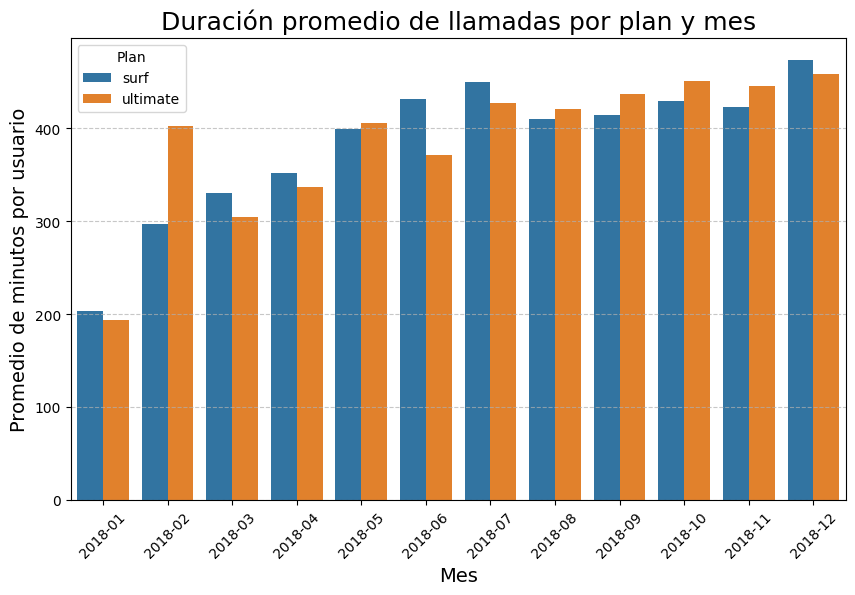

In [42]:
# Agregamos los datos: Calculamos la media de minutos por plan y por mes
# Esto crea una tabla resumen donde cada fila es el promedio real del grupo
promedio_llamadas_plan = datos_usuarios_mes.groupby(['mes', 'plan'])['minutos_totales'].mean().reset_index()

# Ordenamos cronológicamente (usando la columna 'mes')
promedio_llamadas_plan = promedio_llamadas_plan.sort_values('mes')

# Convertimos a string para el eje X
promedio_llamadas_plan['mes_str'] = promedio_llamadas_plan['mes'].astype(str)

# Graficamos usando la tabla ya promediada
plt.figure(figsize=(10, 6))
sns.barplot(
    data=promedio_llamadas_plan, 
    x='mes_str',
    y='minutos_totales', 
    hue='plan'
)

plt.title('Duración promedio de llamadas por plan y mes', fontsize=18)
plt.xlabel('Mes', fontsize=14)
plt.ylabel('Promedio de minutos por usuario', fontsize=14)
plt.legend(title='Plan')
plt.xticks(rotation=45) 
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

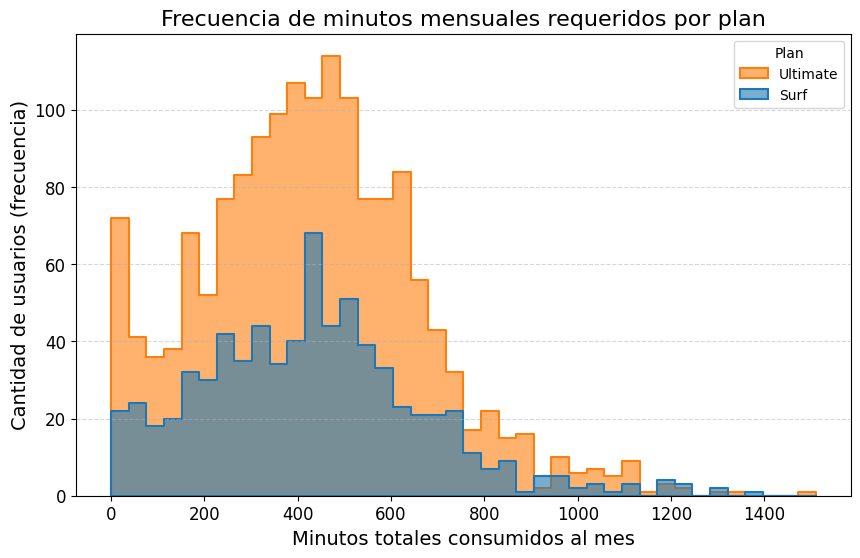

In [43]:
# Comparamos el número de minutos mensuales que necesitan los usuarios de cada plan. Trazamos un histograma.

plt.figure(figsize=(10, 6))

# Usamos un histograma superpuesto.
sns.histplot(
    data=datos_usuarios_mes,
    x='minutos_totales',
    hue='plan',
    bins=40,
    alpha=0.6,
    element='step',
    linewidth=1.5
)

# Etiquetas
plt.title('Frecuencia de minutos mensuales requeridos por plan', fontsize=16)
plt.xlabel('Minutos totales consumidos al mes', fontsize=14)
plt.ylabel('Cantidad de usuarios (frecuencia)', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Plan', labels=['Ultimate', 'Surf']) 
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()


Como hay mas usuarios en el plan <i>surf</i> que en el plan <i>ultimate</i>, se normalizarán los datos para comparar el comportamiento de los usuarios de cada plan sin que el número de usuarios influya en la comparación.

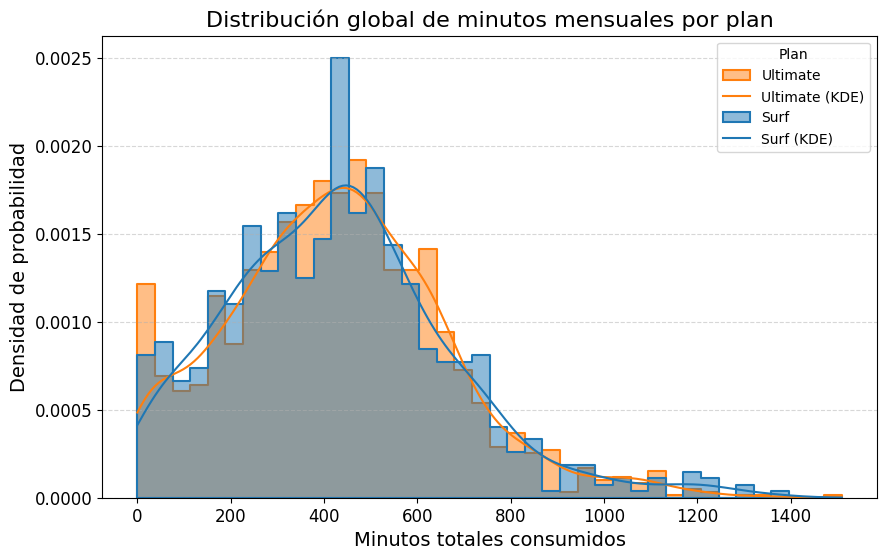

In [44]:
# Distribución global de minutos mensuales por plan. 
plt.figure(figsize=(10, 6))

sns.histplot(
    data=datos_usuarios_mes,
    x='minutos_totales',
    hue='plan',
    kde=True,
    alpha=0.5,
    stat='density',         # Normaliza las áreas
    common_norm=False,      # Normaliza cada plan de manera independiente
    bins=40,
    element='step',
    linewidth=1.5
)

# Etiquetas
plt.title('Distribución global de minutos mensuales por plan', fontsize=16)
plt.xlabel('Minutos totales consumidos', fontsize=14)
plt.ylabel('Densidad de probabilidad', fontsize=14)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
plt.legend(title='Plan', labels=['Ultimate', 'Ultimate (KDE)', 'Surf', 'Surf (KDE)'])
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

Ahora se calcula la media y la varianza de la duración de las llamadas para averiguar si los usuarios de los distintos planes se comportan de forma diferente al realizar sus llamadas. También se incluirán el número de usuarios, la mediana, la desviación estándar, así como el valor máximoy mínimo de minutos consumidos por cada plan.

In [45]:
# Calculamos la media y la varianza de la duración mensual de llamadas.

# Análisis estadístico detallado usando
estadisticas_llamadas_mes = datos_usuarios_mes.groupby(['plan', 'mes'])['minutos_totales'].agg(
    usuarios=('count'),
    media=('mean'),
    mediana=('median'),
    varianza=('var'),
    desv_est=('std'),
    minimo=('min'),
    maximo=('max')
).reset_index()

# Redondeamos a 2 decimales para que la tabla sea legible
estadisticas_llamadas_mes = estadisticas_llamadas_mes.round(2)

estadisticas_llamadas_mes.head(13)
#estadisticas_llamadas_mes.tail()

,plan,mes,usuarios,media,mediana,varianza,desv_est,minimo,maximo
0,surf,2018-01,2,203.00,203.0,15842.00,125.87,114,292
1,surf,2018-02,9,297.00,254.0,52226.50,228.53,39,811
2,surf,2018-03,23,330.00,334.0,35809.36,189.23,35,788
3,surf,2018-04,50,351.54,339.5,50866.74,225.54,16,1043
4,surf,2018-05,77,399.58,415.0,59754.22,244.45,0,1055
5,surf,2018-06,97,431.30,423.0,45592.63,213.52,0,1033
6,surf,2018-07,121,449.98,454.0,61005.10,246.99,0,1176
7,surf,2018-08,162,410.11,392.0,54344.65,233.12,0,1102
8,surf,2018-09,194,414.23,426.0,46595.96,215.86,0,1212
9,surf,2018-10,237,429.73,432.0,52278.66,228.65,0,1227


In [46]:
tarifas.head()

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


In [47]:
# Análisis estadístico global
estadisticas_globales_llamadas = datos_usuarios_mes.groupby('plan')['minutos_totales'].agg(
    usuarios=('count'),
    media=('mean'),
    mediana=('median'),
    varianza=('var'),
    desv_est=('std')
).reset_index().round(2)

print("\n--- Resumen Estadístico Global por Plan ---")
print(estadisticas_globales_llamadas)


--- Resumen Estadístico Global por Plan ---
       plan  usuarios   media  mediana  varianza  desv_est
0      surf      1573  428.75    425.0  54968.28    234.45
1  ultimate       720  430.45    424.0  57844.46    240.51


In [48]:
# Porcentaje de usuarios que consumen más minutos de los que su plan surf ofrece
# usando scipy y cdf con la media y desviación estandar ya calculadas en estadisticas_globales_llamadas
from scipy.stats import norm
# Extraemos la media y desviación estándar para el plan surf
media_surf = estadisticas_globales_llamadas.loc[estadisticas_globales_llamadas['plan'] == 'surf', 'media'].values[0]
desv_est_surf = estadisticas_globales_llamadas.loc[estadisticas_globales_llamadas['plan'] == 'surf', 'desv_est'].values[0]
# El plan surf ofrece 500 minutos incluidos, por lo que calculamos el porcentaje de usuarios que consumen más de 500 minutos
porcentaje_surf_exceso = (1 - norm.cdf(500, loc=media_surf, scale=desv_est_surf)) * 100
print(f"\nPorcentaje de usuarios del plan Surf que consumen más de 500 minutos: {porcentaje_surf_exceso:.2f}%")


Porcentaje de usuarios del plan Surf que consumen más de 500 minutos: 38.06%


Al analizar las estadísticas globales del comportamiento del consumo de minutos de los usuarios de ambos planes podemos ver algo importante. Si bien ambos usuarios consumen en promedio los mismos minutos, la desviación estándar de los usuarios del plan surf indica que hay bastantes usuarios usando más minutos de los que su plan ofrece, alrededor del 37.97 % superan los minutos de su plan, esto podría generar que el costo promedio de facturación de los usuarios del pla surf incremente considerablemente.

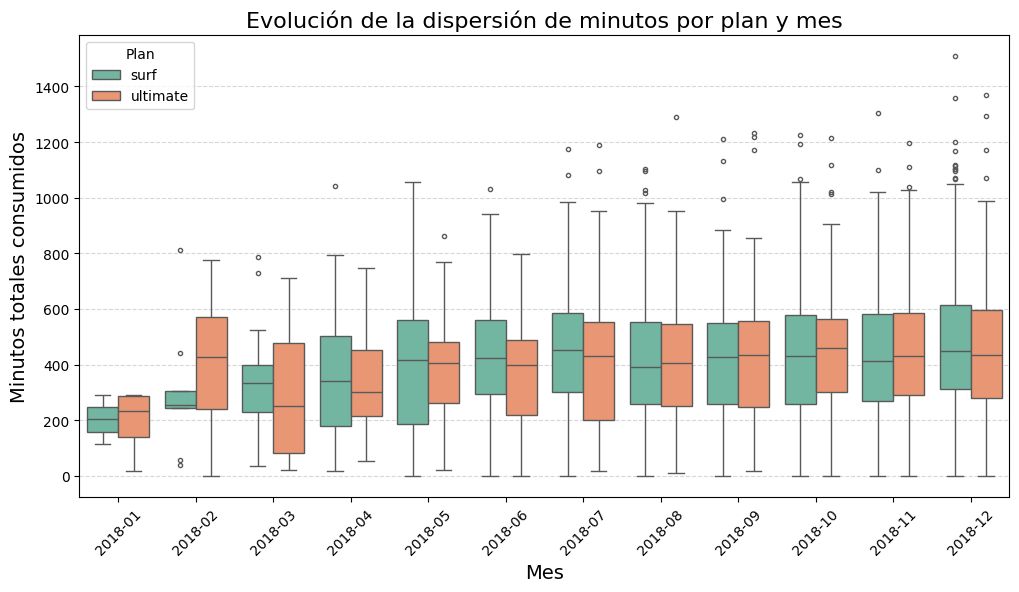

In [49]:
# Trazamos un diagrama de caja para visualizar la distribución de la duración mensual de llamadas

# Agreagamos columna de str para el eje X para usar sns
datos_usuarios_mes['mes_str'] = datos_usuarios_mes['mes'].astype(str)
datos_usuarios_mes = datos_usuarios_mes.sort_values('mes')

# Gráfica de caja y bigote
plt.figure(figsize=(12, 6))

# Dibujamos el boxplot agrupado
sns.boxplot(
    data=datos_usuarios_mes,
    x='mes_str',
    y='minutos_totales',
    hue='plan',
    palette='Set2',       # Una paleta de colores suave para diferenciar bien las cajas
    fliersize=3           # Tamaño de los puntos atípicos
)

plt.title('Evolución de la dispersión de minutos por plan y mes', fontsize=16)
plt.xlabel('Mes', fontsize=14)
plt.ylabel('Minutos totales consumidos', fontsize=14)
plt.legend(title='Plan')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

In [50]:
#datos_usuarios_mes = datos_usuarios_mes.drop(columns={'mes_str'})

In [51]:
tarifas.head()

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


Algunos comportamientos que podemos destacar es que tanto el número de usuarios como el promedio de minutos consumidos crece mes con mes en ambos planes, los promedios más altos de minutos usados son en diciembre, esto podría ser por las fechas festivas. De forma semejante se pueden ver varios outliers, en la gráfica de caja y bigote, en cuanto los meses pasan.

El promedio global de minutos usados es de 428.26 y 423.94 para <i>surf</i> y <i>ultimate</i> respectivamente con una desviación estándar también muy semejante de 234.19 y 240.21 respectivamente. Sin embargo, ya que hay más usuarios en el plan <i>surf</i> el histograma de frecuencias muestra una superioridad del usuarios en cada valores de minutos, por ellos se normalizó la gráfica, para ver un comportamiento independiente del número de usuarios. Esto es interesante porque el paquete ultimate ofrece 2500 minutos más, es decir, 3000 totales contra 500 minutos del plan surf.

El comportamiento, en función del plan, de los usuarios es muy semejante, el plan <i>surf</i> tiene un promedio de minutos consumidos semejante el plan <i>ultimate</i>, la desviación estándar también es semejante. Al normalizar los datos para comparar el comportamiento de los usuarios de cada plan sin que el número de usuarios influya en la comparación, se observa que ambos planes tienen un comportamiento similar en cuanto a la distribución de minutos consumidos por mes, con picos en diciembre y una tendencia general al alza a lo largo del año. Esto sugiere que aunque el plan <i>surf</i> tiene más usuarios, el comportamiento de consumo de minutos arece no varíiar significativamente entre los dos planes. Hace falta una prueba de hipótesis para determinar si la diferencia en el promedio de minutos consumidos entre los dos planes es estadísticamente significativa.

### Mensajes

In [52]:
datos_usuarios_mes.head()

,user_id,mes,llamadas_totales,minutos_totales,mensajes_totales,volumen_total_mb,volumen_total_gb,plan,usd_plan_mes,cargos_adicionales,costo_total,mes_str
156,1042,2018-01,18,114,0.0,1854.93,2,surf,20,0.0,20.0,2018-01
882,1185,2018-01,23,181,0.0,6812.77,7,ultimate,70,0.0,70.0,2018-01
361,1077,2018-01,42,290,37.0,10635.64,11,ultimate,70,0.0,70.0,2018-01
1676,1362,2018-01,42,292,21.0,7894.79,8,surf,20,0.0,20.0,2018-01
1019,1214,2018-01,5,16,2.0,1315.35,2,ultimate,70,0.0,70.0,2018-01


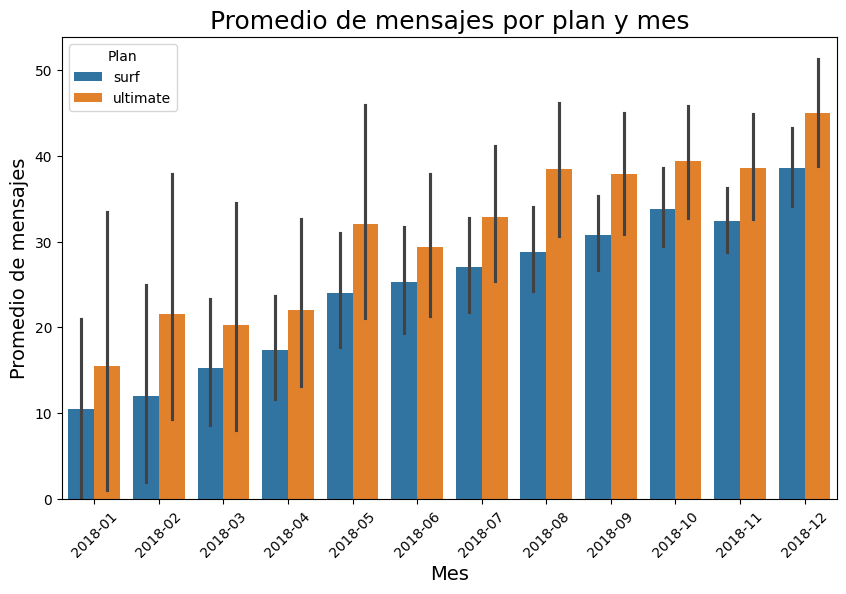

In [53]:
# Comparamos el promedio de mensajes por cada plan y por cada mes. Trazamos un gráfico de barras para visualizarla.

# Graficamos usando la nueva columna de texto
plt.figure(figsize=(10, 6))
sns.barplot(
    data=datos_usuarios_mes, 
    x='mes_str',
    y='mensajes_totales', 
    hue='plan'
)

plt.title('Promedio de mensajes por plan y mes', fontsize=18)
plt.xlabel('Mes', fontsize=14)
plt.ylabel('Promedio de mensajes', fontsize=14)
plt.legend(title='Plan')

plt.xticks(rotation=45) 

plt.show()

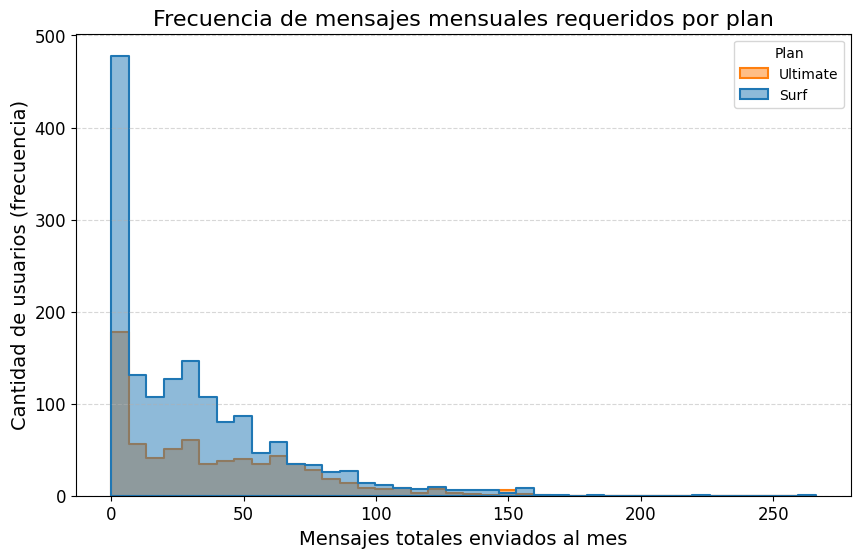

In [54]:
# Comparamos el número de mensajes mensuales que necesitan los usuarios de cada plan. Trazamos un histograma.

plt.figure(figsize=(10, 6))

# Usamos un histograma superpuesto.
sns.histplot(
    data=datos_usuarios_mes,
    x='mensajes_totales',
    hue='plan',
    bins=40,
    alpha=0.5,
    element='step',
    linewidth=1.5
)

# Etiquetas
plt.title('Frecuencia de mensajes mensuales requeridos por plan', fontsize=16)
plt.xlabel('Mensajes totales enviados al mes', fontsize=14)
plt.ylabel('Cantidad de usuarios (frecuencia)', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Plan', labels=['Ultimate', 'Surf']) 
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

Como hay mas usuarios en el plan <i>surf</i> que en el plan <i>ultimate</i>, se normalizarán los datos para comparar el comportamiento de los usuarios de cada plan sin que el número de usuarios influya en la comparación.

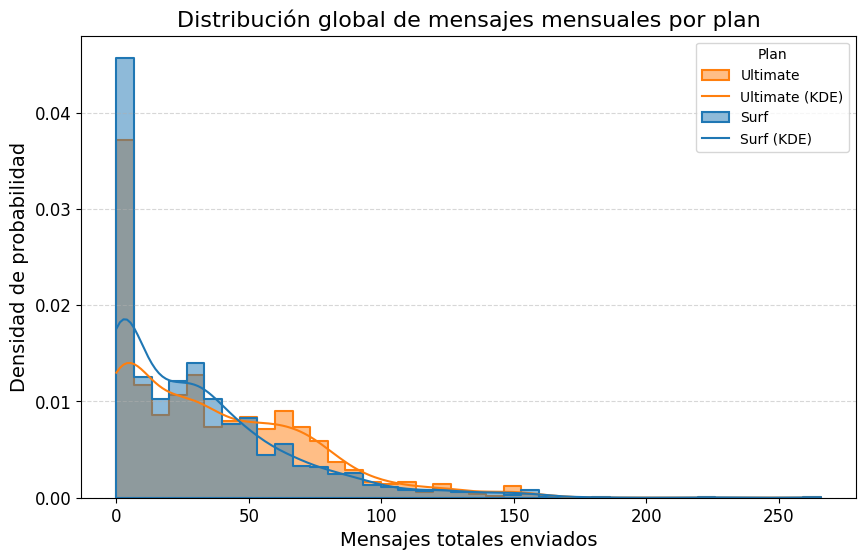

In [55]:
# Distribución global de mensajes mensuales por plan. 
plt.figure(figsize=(10, 6))

sns.histplot(
    data=datos_usuarios_mes,
    x='mensajes_totales',
    hue='plan',
    kde=True,
    alpha=0.5,
    stat='density',         # Normaliza las áreas
    common_norm=False,      # Normaliza cada plan de manera independiente
    bins=40,
    element='step',
    linewidth=1.5
)

# Etiquetas
plt.title('Distribución global de mensajes mensuales por plan', fontsize=16)
plt.xlabel('Mensajes totales enviados', fontsize=14)
plt.ylabel('Densidad de probabilidad', fontsize=14)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
plt.legend(title='Plan', labels=['Ultimate', 'Ultimate (KDE)', 'Surf', 'Surf (KDE)'])
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

Ahora se calcula la media y la varianza de la duración de las llamadas para averiguar si los usuarios de los distintos planes se comportan de forma diferente al realizar sus llamadas. También se incluirán el número de usuarios, la mediana, la desviación estándar, así como el valor máximoy mínimo de minutos consumidos por cada plan.

In [56]:
# Calculamos la media y la varianza de la cantidad de mensajes enviados por mes.

# Análisis estadístico detallado usando
estadisticas_mensajes_mes = datos_usuarios_mes.groupby(['plan', 'mes'])['mensajes_totales'].agg(
    usuarios=('count'),
    media=('mean'),
    mediana=('median'),
    varianza=('var'),
    desv_est=('std'),
    minimo=('min'),
    maximo=('max')
).reset_index()

# Redondeamos a 2 decimales para que la tabla sea legible
estadisticas_mensajes_mes = estadisticas_mensajes_mes.round(2)

estadisticas_mensajes_mes.head(13)
#estadisticas_mensajes_mes.tail()

,plan,mes,usuarios,media,mediana,varianza,desv_est,minimo,maximo
0,surf,2018-01,2,10.50,10.5,220.50,14.85,0.0,21.0
1,surf,2018-02,9,12.00,3.0,386.00,19.65,0.0,58.0
2,surf,2018-03,23,15.26,7.0,346.57,18.62,0.0,59.0
3,surf,2018-04,50,17.40,10.0,501.59,22.40,0.0,120.0
4,surf,2018-05,77,24.01,15.0,847.20,29.11,0.0,149.0
5,surf,2018-06,97,25.30,15.0,914.92,30.25,0.0,133.0
6,surf,2018-07,121,27.03,20.0,923.92,30.40,0.0,164.0
7,surf,2018-08,162,28.78,20.0,1029.52,32.09,0.0,156.0
8,surf,2018-09,194,30.76,22.5,1003.83,31.68,0.0,153.0
9,surf,2018-10,237,33.84,26.0,1275.47,35.71,0.0,224.0


In [57]:
tarifas.head()

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


In [58]:
# Análisis estadístico global
estadisticas_globales_mensajes = datos_usuarios_mes.groupby('plan')['mensajes_totales'].agg(
    usuarios=('count'),
    media=('mean'),
    mediana=('median'),
    varianza=('var'),
    desv_est=('std')
).reset_index().round(2)

print("\n--- Resumen estadístico global de mensajes enviados por plan ---")
print(estadisticas_globales_mensajes)


--- Resumen estadístico global de mensajes enviados por plan ---
       plan  usuarios  media  mediana  varianza  desv_est
0      surf      1573  31.16     24.0   1126.72     33.57
1  ultimate       720  37.55     30.0   1208.76     34.77


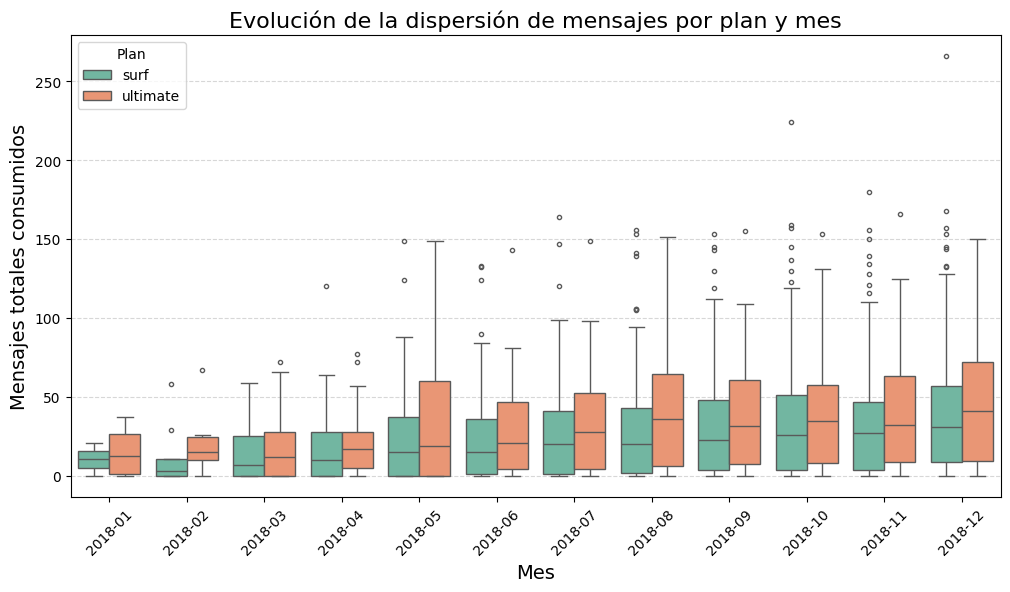

In [59]:
# Trazamos un diagrama de caja para visualizar la distribución de los mensajes enviados mensualmente

# Gráfica de caja y bigote
plt.figure(figsize=(12, 6))

# Dibujamos el boxplot agrupado
sns.boxplot(
    data=datos_usuarios_mes,
    x='mes_str',
    y='mensajes_totales',
    hue='plan',
    palette='Set2',       # Una paleta de colores suave para diferenciar bien las cajas
    fliersize=3           # Tamaño de los puntos atípicos
)

plt.title('Evolución de la dispersión de mensajes por plan y mes', fontsize=16)
plt.xlabel('Mes', fontsize=14)
plt.ylabel('Mensajes totales consumidos', fontsize=14)
plt.legend(title='Plan')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

In [60]:
#datos_usuarios_mes = datos_usuarios_mes.drop(columns={'mes_str'})

In [61]:
tarifas.head()

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


<p>Algunos comportamientos que podemos destacar son que tanto el número de usuarios como el promedio de mensajes enviados crecen mes con mes en ambos planes. Los promedios más altos se registran en diciembre, lo cual podría atribuirse a las festividades de fin de año. De forma semejante, en las gráficas de caja y bigote se observan varios valores atípicos (<i>outliers</i>) conforme transcurren los meses; aunque este crecimiento no es tan marcado como en el caso de los minutos consumidos, el plan Surf presenta una mayor cantidad de estos valores.</p>

<p>Los promedios globales de mensajes enviados son de <b>31.16</b> para el plan <b>Surf</b> y <b>37.55</b> para el plan <b>Ultimate</b>, con desviaciones estándar de <b>33.57</b> y <b>34.77</b>, respectivamente. Aunque el promedio en <b>Ultimate</b> es superior, el histograma de frecuencias original mostraba una aparente dominancia del plan <b>Surf</b> en todos los rangos de consumo debido a su mayor volumen de usuarios. Por ello, se procedió a normalizar la gráfica para comparar el comportamiento de forma independiente al tamaño de la muestra. Tras la normalización, se observa que, pese a que el plan <b>Ultimate</b> ofrece un límite de 1000 mensajes frente a los 50 del plan <b>Surf</b>, los patrones de consumo real de los usuarios en ambos planes guardan una distribución comparable.</p>

<p>En conclusión, el comportamiento de los usuarios en función del plan es muy semejante. Si bien el plan <b>Ultimate</b> mantiene un promedio de mensajes enviados ligeramente mayor al plan <b>Surf</b>, las distribuciones de ambos muestran picos en diciembre y una tendencia general al alza a lo largo del año. Esto sugiere que, aunque el plan <b>Surf</b> tiene una base de usuarios más amplia, el envío de mensajes es individualmente más intensivo en el plan <b>Ultimate</b>. Finalmente, se requiere de una prueba de hipótesis para determinar si esta diferencia de <b>6.39</b> mensajes en el promedio global es estadísticamente significativa o producto del azar.</p>

### Internet

In [62]:
datos_usuarios_mes.head()

,user_id,mes,llamadas_totales,minutos_totales,mensajes_totales,volumen_total_mb,volumen_total_gb,plan,usd_plan_mes,cargos_adicionales,costo_total,mes_str
156,1042,2018-01,18,114,0.0,1854.93,2,surf,20,0.0,20.0,2018-01
882,1185,2018-01,23,181,0.0,6812.77,7,ultimate,70,0.0,70.0,2018-01
361,1077,2018-01,42,290,37.0,10635.64,11,ultimate,70,0.0,70.0,2018-01
1676,1362,2018-01,42,292,21.0,7894.79,8,surf,20,0.0,20.0,2018-01
1019,1214,2018-01,5,16,2.0,1315.35,2,ultimate,70,0.0,70.0,2018-01


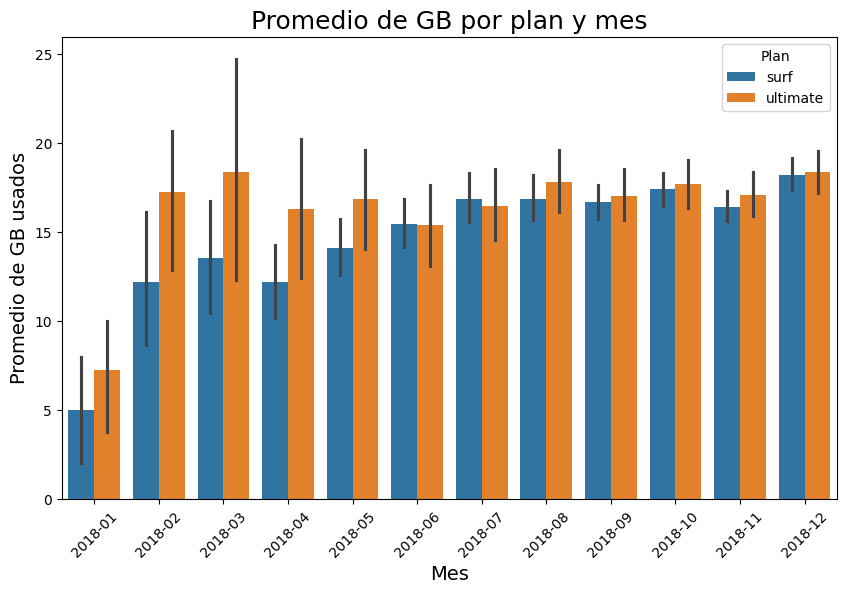

In [63]:
# Comparamos los GB promedio por cada plan y por cada mes. Trazamos un gráfico de barras para visualizarla.

# Ordenamos los meses
datos_usuarios_mes = datos_usuarios_mes.sort_values('mes_str')

# Graficamos usando la nueva columna de texto
plt.figure(figsize=(10, 6))
sns.barplot(
    data=datos_usuarios_mes, 
    x='mes_str',
    y='volumen_total_gb', 
    hue='plan'
)

plt.title('Promedio de GB por plan y mes', fontsize=18)
plt.xlabel('Mes', fontsize=14)
plt.ylabel('Promedio de GB usados', fontsize=14)
plt.legend(title='Plan')

plt.xticks(rotation=45) 

plt.show()

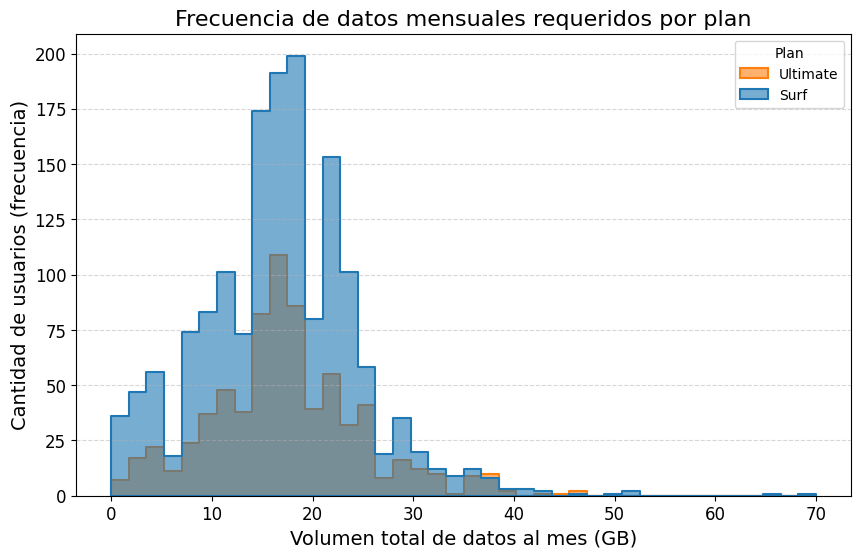

In [64]:
# Comparamos la cantidad de datos mensuales que necesitan los usuarios de cada plan. Trazamos un histograma.

plt.figure(figsize=(10, 6))

# Usamos un histograma superpuesto.
sns.histplot(
    data=datos_usuarios_mes,
    x='volumen_total_gb',
    hue='plan',
    bins=40,
    alpha=0.6,
    element='step',
    linewidth=1.5
)

# Etiquetas
plt.title('Frecuencia de datos mensuales requeridos por plan', fontsize=16)
plt.xlabel('Volumen total de datos al mes (GB)', fontsize=14)
plt.ylabel('Cantidad de usuarios (frecuencia)', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Plan', labels=['Ultimate', 'Surf']) 
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

Esta primera gráfica muestra promedios semejantes lo que indica que hay bastantes personas del plan surf que consumen más datos de los que su plan proporciona mientras que en el plan ultimate hay usuarios que consumen menos datos de los que su plan proporciona. Esto es interesante porque el paquete ultimate ofrece 15 GB más, es decir, 30 GB totales contra 15 GB del plan surf.

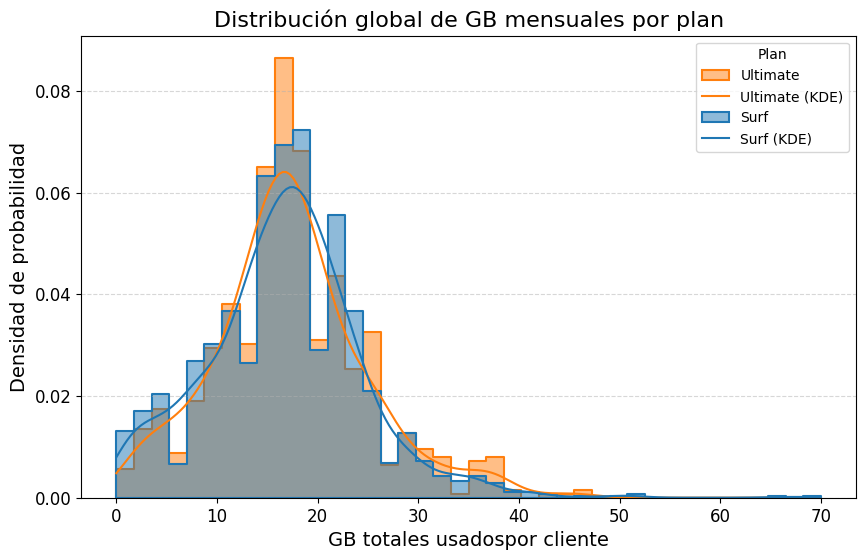

In [65]:
# Distribución global de datos mensuales por plan. 
plt.figure(figsize=(10, 6))

sns.histplot(
    data=datos_usuarios_mes,
    x='volumen_total_gb',
    hue='plan',
    kde=True,
    alpha=0.5,
    stat='density',         # Normaliza las áreas
    common_norm=False,      # Normaliza cada plan de manera independiente
    bins=40,
    element='step',
    linewidth=1.5
)

# Etiquetas
plt.title('Distribución global de GB mensuales por plan', fontsize=16)
plt.xlabel('GB totales usadospor cliente', fontsize=14)
plt.ylabel('Densidad de probabilidad', fontsize=14)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
plt.legend(title='Plan', labels=['Ultimate', 'Ultimate (KDE)', 'Surf', 'Surf (KDE)'])
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

Este pico más alto del plan ultimate indica que hay más concentración de GB consumidos alrededor del mismo valor, es decir, hay menos dispersión en el consumo de los datos.

Para confirmar esto se calculará la media, varianza, número de elementos, desviación estándar, y valores mínimos y máximos del conjunto de datos.

In [66]:
# Calculamos la media y la varianza de los datos consumidos durante el mes.

# Análisis estadístico detallado usando
estadisticas_datos_mes = datos_usuarios_mes.groupby(['plan', 'mes'])['volumen_total_gb'].agg(
    usuarios=('count'),
    media=('mean'),
    mediana=('median'),
    varianza=('var'),
    desv_est=('std'),
    minimo=('min'),
    maximo=('max')
).reset_index()

# Redondeamos a 2 decimales para que la tabla sea legible
estadisticas_datos_mes = estadisticas_datos_mes.round(2)

estadisticas_datos_mes.head(13)
#estadisticas_datos_mes.tail()

,plan,mes,usuarios,media,mediana,varianza,desv_est,minimo,maximo
0,surf,2018-01,2,5.00,5.0,18.00,4.24,2,8
1,surf,2018-02,9,12.22,12.0,41.44,6.44,1,20
2,surf,2018-03,23,13.57,14.0,63.98,8.00,2,30
3,surf,2018-04,50,12.22,12.0,56.22,7.50,0,28
4,surf,2018-05,77,14.12,14.0,58.18,7.63,0,36
5,surf,2018-06,97,15.48,16.0,47.75,6.91,0,37
6,surf,2018-07,121,16.88,17.0,61.48,7.84,0,39
7,surf,2018-08,162,16.88,17.0,71.42,8.45,0,51
8,surf,2018-09,194,16.69,17.0,49.24,7.02,0,37
9,surf,2018-10,237,17.41,18.0,60.73,7.79,0,46


In [67]:
# Análisis estadístico global
estadisticas_globales_datos = datos_usuarios_mes.groupby('plan')['volumen_total_gb'].agg(
    usuarios=('count'),
    media=('mean'),
    mediana=('median'),
    varianza=('var'),
    desv_est=('std')
).reset_index().round(2)

print("\n--- Resumen estadístico global de datos usados por plan ---")
print(estadisticas_globales_datos)


--- Resumen estadístico global de datos usados por plan ---
       plan  usuarios  media  mediana  varianza  desv_est
0      surf      1573  16.67     17.0     61.58      7.85
1  ultimate       720  17.31     17.0     58.83      7.67


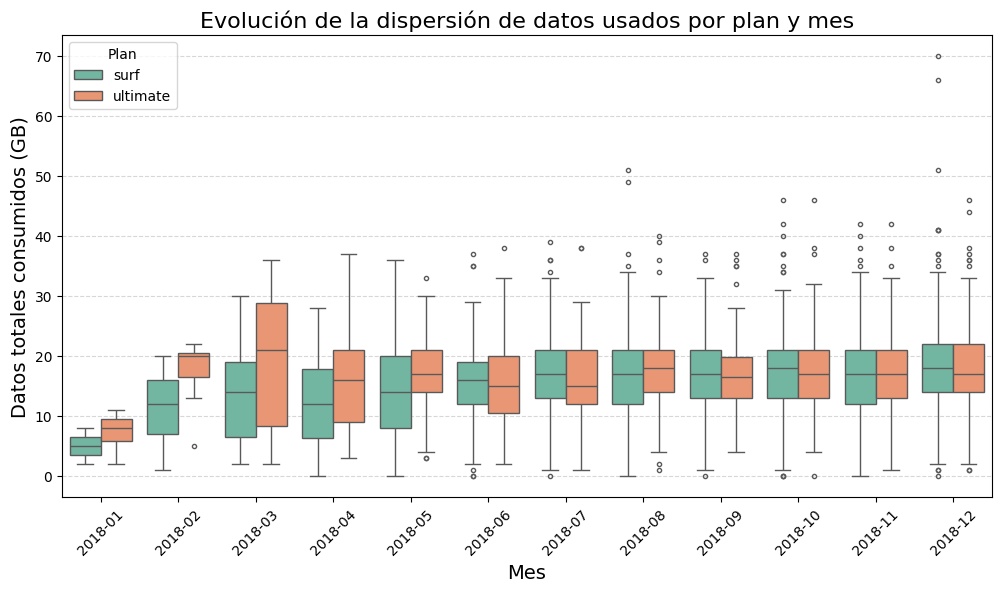

In [68]:
# Trazamos un diagrama de caja para visualizar la distribución de los datos consumidos al mes

# Gráfica de caja y bigote
plt.figure(figsize=(12, 6))

# Dibujamos el boxplot agrupado
sns.boxplot(
    data=datos_usuarios_mes,
    x='mes_str',
    y='volumen_total_gb',
    hue='plan',
    palette='Set2',       # Una paleta de colores suave para diferenciar bien las cajas
    fliersize=3           # Tamaño de los puntos atípicos
)

plt.title('Evolución de la dispersión de datos usados por plan y mes', fontsize=16)
plt.xlabel('Mes', fontsize=14)
plt.ylabel('Datos totales consumidos (GB)', fontsize=14)
plt.legend(title='Plan')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

In [69]:
#datos_usuarios_mes = datos_usuarios_mes.drop(columns={'mes_str'})

<p>Al comparar el consumo mensual de datos, visualizamos un valor promedio ligeramente superior en el plan <b>Ultimate</b>. Esto resulta lógico dado que disponen de un límite mayor; sin embargo, a nivel de volumen absoluto, el consumo promedio entre ambos planes es notablemente cercano. La verdadera diferencia surge al analizar la <b>densidad de probabilidad</b>: el comportamiento de los usuarios de <b>Ultimate</b> está más concentrado y contenido dentro de sus límites, mientras que en <b>Surf</b> la distribución se desplaza frecuentemente hacia la zona de excedentes, esta zona sobrepasa los límites de su plan.</p>

<p>Esta diferencia en la dispersión se confirma con los valores globales: la media es de <b>16.67 GB para Surf</b> y <b>17.31 GB para Ultimate</b>, con desviaciones estándar de <b>7.85 GB y 7.67 GB</b>, respectivamente. <b>En conclusión, aunque el centro de ambas poblaciones es estadísticamente similar, el comportamiento de uso difiere críticamente en su relación con el límite del contrato</b>: los usuarios de Surf operan en un régimen de insuficiencia, mientras que los de Ultimate consumen con holgura.</p>

<p>En cuanto a los datos atípicos, <b>observamos nuevamente una mayor presencia de usuarios del plan Surf</b> que consumen más datos de los que su paquete proporciona (superando los 15 GB). Por el contrario, en el plan <b>Ultimate existen usuarios que consumen mucho menos de lo que su límite de 30 GB permite</b>. Nuevamente, en diciembre se registra una alta concentración de <i>outliers</i>, sugiriendo una estacionalidad en el consumo máximo.</p>

<p>Este fenómeno indica que el plan Surf no satisface completamente las necesidades de su base de usuarios, obligándolos a incurrir en costos adicionales. Por otro lado, el plan Ultimate parece estar sobredimensionado para una parte de sus clientes, quienes no aprovechan la totalidad de los datos contratados. Para la empresa, esto representa una oportunidad estratégica: el plan Surf actúa como un motor de ingresos por excedentes, mientras que el Ultimate funciona como un producto de «tranquilidad» para usuarios que prefieren pagar una prima por no preocuparse por sus límites.</p>

## Ingreso

Del mismo modo que se ha estudiado el comportamiento de los usuarios, se describen estadísticamente los ingresos de los planes.

In [70]:
datos_usuarios_mes.head()

,user_id,mes,llamadas_totales,minutos_totales,mensajes_totales,volumen_total_mb,volumen_total_gb,plan,usd_plan_mes,cargos_adicionales,costo_total,mes_str
156,1042,2018-01,18,114,0.0,1854.93,2,surf,20,0.0,20.0,2018-01
882,1185,2018-01,23,181,0.0,6812.77,7,ultimate,70,0.0,70.0,2018-01
361,1077,2018-01,42,290,37.0,10635.64,11,ultimate,70,0.0,70.0,2018-01
1676,1362,2018-01,42,292,21.0,7894.79,8,surf,20,0.0,20.0,2018-01
1019,1214,2018-01,5,16,2.0,1315.35,2,ultimate,70,0.0,70.0,2018-01


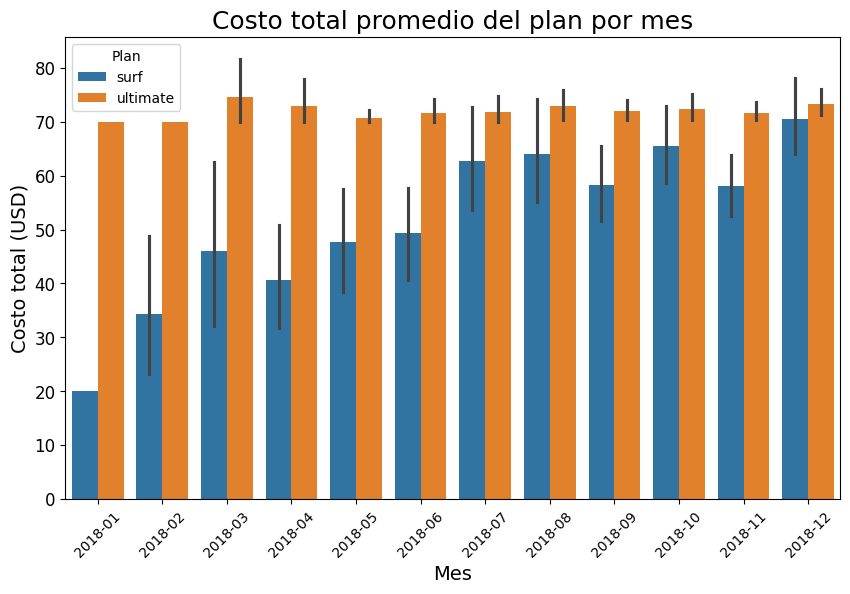

In [71]:
# Comparamos el costo total por cada plan y por cada mes. Trazamos un gráfico de barras para visualizarlo.
# Graficamos usando la nueva columna de texto
plt.figure(figsize=(10, 6))
sns.barplot(
    data=datos_usuarios_mes, 
    x='mes_str',
    y='costo_total', 
    hue='plan'
)

plt.title('Costo total promedio del plan por mes', fontsize=18)
plt.xlabel('Mes', fontsize=14)
plt.ylabel('Costo total (USD)', fontsize=14)
plt.legend(title='Plan')
plt.yticks(fontsize=12)
plt.xticks(rotation=45) 

plt.show()

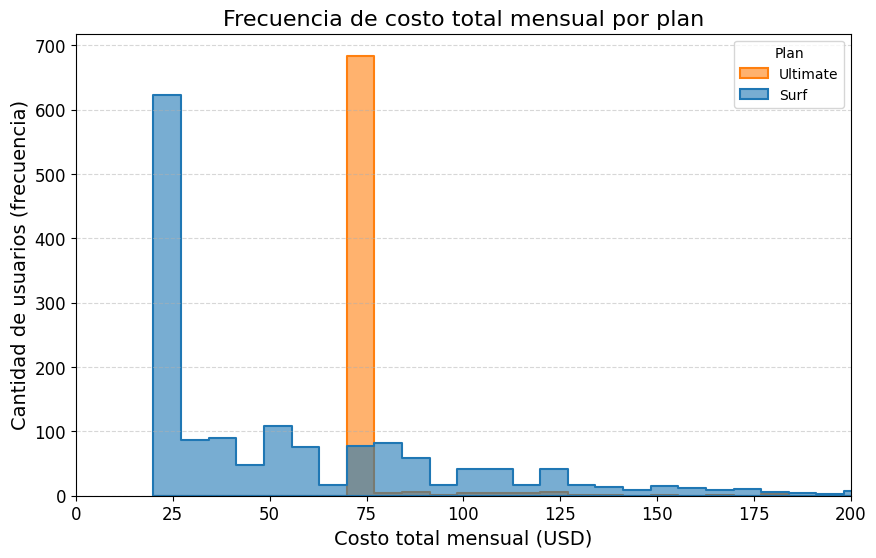

In [72]:
# Comparamos el costo total mensual que pagan los usuarios de cada plan. Trazamos un histograma.

plt.figure(figsize=(10, 6))

# Usamos un histograma superpuesto.
sns.histplot(
    data=datos_usuarios_mes,
    x='costo_total',
    hue='plan',
    bins=80,
    alpha=0.6,
    element='step',
    linewidth=1.5
)

# Etiquetas
plt.title('Frecuencia de costo total mensual por plan', fontsize=16)
plt.xlabel('Costo total mensual (USD)', fontsize=14)
plt.ylabel('Cantidad de usuarios (frecuencia)', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Plan', labels=['Ultimate', 'Surf']) 
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xlim(0,200)

plt.show()

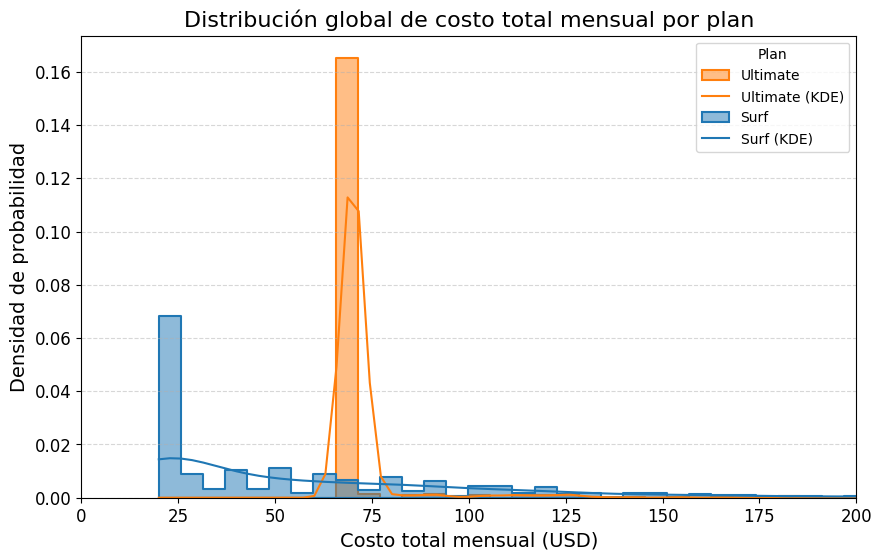

In [73]:
# Distribución global del costo total mensual por plan. 
plt.figure(figsize=(10, 6))

sns.histplot(
    data=datos_usuarios_mes,
    x='costo_total',
    hue='plan',
    kde=True,
    alpha=0.5,
    stat='density',         # Normaliza las áreas
    common_norm=False,      # Normaliza cada plan de manera independiente
    bins=100,
    element='step',
    linewidth=1.5
)

# Etiquetas
plt.title('Distribución global de costo total mensual por plan', fontsize=16)
plt.xlabel('Costo total mensual (USD)', fontsize=14)
plt.ylabel('Densidad de probabilidad', fontsize=14)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
plt.legend(title='Plan', labels=['Ultimate', 'Ultimate (KDE)', 'Surf', 'Surf (KDE)'])
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xlim(0,200)

plt.show()

Con estos primero gráficos podemos ver varias cosas. De incio, ya que el plan ultimate es más caro, la gráfica del pago promedio de este plan tiene un pico desplazado hacia la derecha respecto al plan surf. Además, tomando como referencia la primera gráfica, es decir, la gráfica de barras, podemos visualizar un comportamiento donde los usuarios del plan surf terminan pagando, en promedio, más de lo que su plan cuesta, eso quiere decir que los usuarios del plan surf consumen mucho más de lo que su plan les proporciona. Este comportamiento ya se esperaba desde el análisis de los minutos consumidos.

Ahora veremos más a detalle este comportamiento de los gastos adicionales y los valores estadísticos globales de los ingresos.

In [74]:
# Análisis de promedio de cobro adicional por llamadas, mensajes y datos, por cada plan y por cada mes. Trazamos un gráfico de barras para visualizarlo.
# se necesita calcular por separado el cobro adicional por llamadas, mensajes y datos, para cada usuario, mes y plan. Después se promedia por plan y mes para graficar.

# Traemos los datos de las tarifas para cada usuario. Después se borrarán las columnas no necesarias
datos_usuarios_mes = datos_usuarios_mes.merge(tarifas, left_on='plan', right_on = 'plan_name', how='left')

# Minutos y costo adicional
minutos_adicionales = (datos_usuarios_mes['minutos_totales'] - datos_usuarios_mes['minutes_included']).clip(lower=0) # para evitar números negativos
costo_minutos_adicionales = minutos_adicionales * datos_usuarios_mes['usd_per_minute']

# Mensaje y costo adicional
mensajes_adicionales = (datos_usuarios_mes['mensajes_totales'] - datos_usuarios_mes['messages_included']).clip(lower=0)
costo_mensajes_adicionales = mensajes_adicionales * datos_usuarios_mes['usd_per_message']

# Tráfico de internet y costo adicional
gb_adicionales = (datos_usuarios_mes['volumen_total_gb'] - (datos_usuarios_mes['mb_per_month_included'] / 1024)).clip(lower=0)
costo_gb_adicionales = gb_adicionales * datos_usuarios_mes['usd_per_gb']

# Columna de costos adicionales 
datos_usuarios_mes['costo_minutos_adicionales'] = costo_minutos_adicionales
datos_usuarios_mes['costo_mensajes_adicionales'] = costo_mensajes_adicionales
datos_usuarios_mes['costo_gb_adicionales'] = costo_gb_adicionales

datos_usuarios_mes.head()

,user_id,mes,llamadas_totales,minutos_totales,mensajes_totales,volumen_total_mb,volumen_total_gb,plan,usd_plan_mes,cargos_adicionales,...,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,costo_minutos_adicionales,costo_mensajes_adicionales,costo_gb_adicionales
0,1042,2018-01,18,114,0.0,1854.93,2,surf,20,0.0,...,15360,500,20,10,0.03,0.03,surf,0.0,0.0,0.0
1,1185,2018-01,23,181,0.0,6812.77,7,ultimate,70,0.0,...,30720,3000,70,7,0.01,0.01,ultimate,0.0,0.0,0.0
2,1077,2018-01,42,290,37.0,10635.64,11,ultimate,70,0.0,...,30720,3000,70,7,0.01,0.01,ultimate,0.0,0.0,0.0
3,1362,2018-01,42,292,21.0,7894.79,8,surf,20,0.0,...,15360,500,20,10,0.03,0.03,surf,0.0,0.0,0.0
4,1214,2018-01,5,16,2.0,1315.35,2,ultimate,70,0.0,...,30720,3000,70,7,0.01,0.01,ultimate,0.0,0.0,0.0


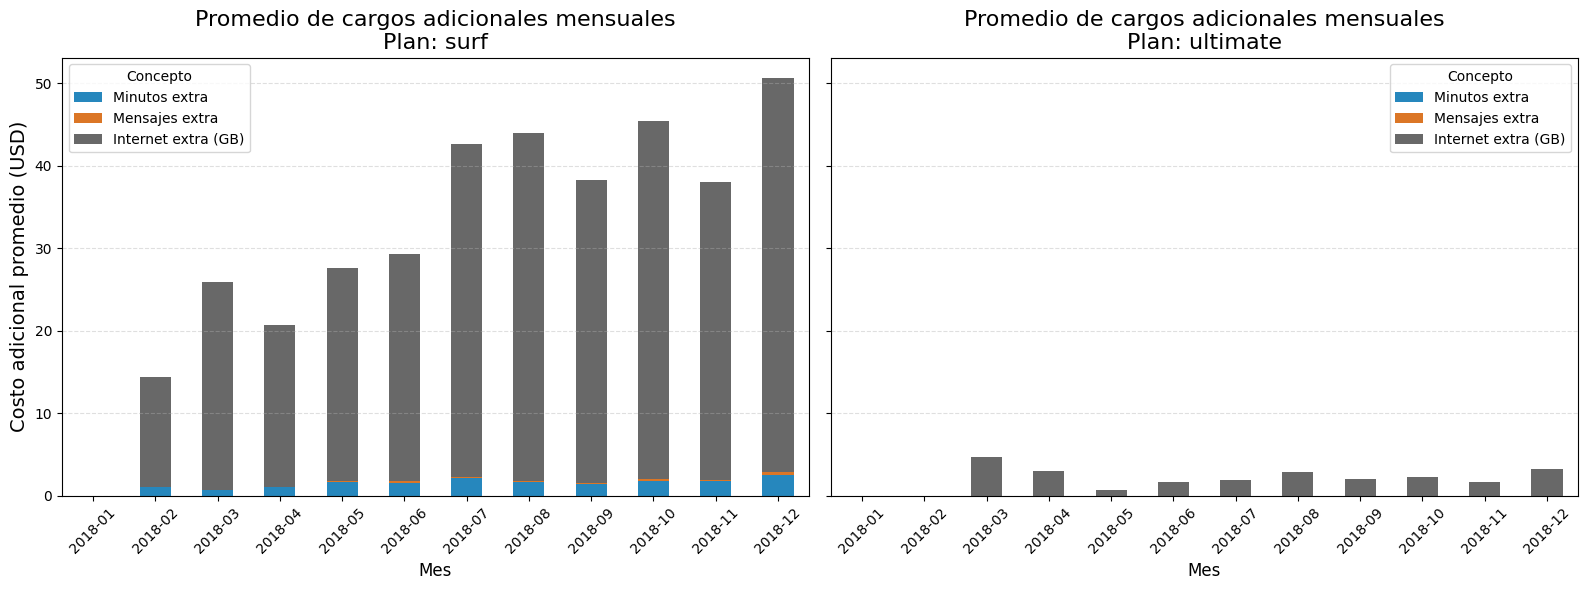

In [75]:
# Agrupamos y promediamos los costos adicionales por mes y por plan
costos_promedio = datos_usuarios_mes.groupby(['mes', 'plan'])[['costo_minutos_adicionales', 'costo_mensajes_adicionales', 'costo_gb_adicionales']].mean().reset_index()

# Para evitar bugs de formato, aseguramos que el mes sea texto ordenado (si usabas period[M])
costos_promedio['mes_str'] = costos_promedio['mes'].astype(str)

# Obtenemos los nombres de los planes para iterar
planes = costos_promedio['plan'].unique()

# Colocamos un gráfico al lado del otro
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Azul fuerte, Naranja brillante, Gris oscuro
colores_grafica = ['#0072B2', '#D55E00', '#4D4D4D']

# Bucle para graficar cada plan en su respectivo panel
for i, plan in enumerate(planes):
    # Filtramos los datos del plan y ponemos el mes como índice
    datos_plan = costos_promedio[costos_promedio['plan'] == plan].set_index('mes_str')
    
    # Nos quedamos solo con las columnas numéricas de costos
    datos_plan = datos_plan[['costo_minutos_adicionales', 'costo_mensajes_adicionales', 'costo_gb_adicionales']]
    
    # Graficamos barras apiladas (stacked=True) directamente desde Pandas
    datos_plan.plot(kind='bar', stacked=True, ax=axes[i], color=colores_grafica, alpha=0.85)
    
    # Estética de cada subgráfico
    axes[i].set_title(f'Promedio de cargos adicionales mensuales\nPlan: {plan}', fontsize=16)
    axes[i].set_xlabel('Mes', fontsize=12)
    
    if i == 0:
        axes[i].set_ylabel('Costo adicional promedio (USD)', fontsize=14)
        
    # Nombres amigables para la leyenda
    axes[i].legend(['Minutos extra', 'Mensajes extra', 'Internet extra (GB)'], title='Concepto')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', linestyle='--', alpha=0.4)

# Ajustamos el espaciado para que no se encimen los textos
plt.tight_layout()
plt.show()



In [76]:
# Análisis estadístico de los costos adicionales

columnas_excedentes = [
    'costo_minutos_adicionales', 
    'costo_mensajes_adicionales', 
    'costo_gb_adicionales'
]

print("\n--- Descripción estadística global de excedentes por plan ---")

# Agrupamos solo por plan y aplicamos describe() a los costos extra
resumen_global_costos = datos_usuarios_mes.groupby('plan')[columnas_excedentes].describe().round(2)

# Transponemos la tabla para que las métricas (mean, std, max) queden como columnas
# Esto hace que sea mucho más legible en Jupyter Notebook
resumen_global_costos = resumen_global_costos.T

resumen_global_costos


--- Descripción estadística global de excedentes por plan ---


plan                                 surf  ultimate
costo_minutos_adicionales  count  1573.00    720.00
                           mean      1.84      0.00
                           std       3.77      0.00
                           min       0.00      0.00
                           25%       0.00      0.00
                           50%       0.00      0.00
                           75%       2.28      0.00
                           max      30.30      0.00
costo_mensajes_adicionales count  1573.00    720.00
                           mean      0.21      0.00
                           std       0.58      0.00
                           min       0.00      0.00
                           25%       0.00      0.00
                           50%       0.00      0.00
                           75%       0.00      0.00
                           max       6.48      0.00
costo_gb_adicionales       count  1573.00    720.00
                           mean     38.65      2.31
                           std      54.46     11.40
                           min       0.00      0.00
                           25%       0.00      0.00
                           50%      20.00      0.00
                           75%      60.00      0.00
                           max     550.00    112.00

Con este análisis podemos ver cosas muy interesantes. El uso de GB excedentes al plan establecido es significativamente mayor en los usuarios del plan surf, además de ser el principal cargo adicional; lo que sugiere que el plan surf no satisface completamente las necesidades de sus usuarios en cuanto a datos, mientras que el plan ultimate parece ser más adecuado para sus usuarios en este aspecto.

Constinuemos analizando el costo final de cada plan, es decir, el costo mensual más los cargos adicionales.

In [77]:
# Calculamos la media y la varianza de los datos consumidos durante el mes.

# Análisis estadístico detallado usando
estadisticas_datos_mes = datos_usuarios_mes.groupby(['plan', 'mes'])['costo_total'].agg(
    usuarios=('count'),
    media=('mean'),
    mediana=('median'),
    varianza=('var'),
    desv_est=('std'),
    minimo=('min'),
    maximo=('max')
).reset_index()

# Redondeamos a 2 decimales para que la tabla sea legible
estadisticas_datos_mes = estadisticas_datos_mes.round(2)

estadisticas_datos_mes.head(13)
#estadisticas_datos_mes.tail()

,plan,mes,usuarios,media,mediana,varianza,desv_est,minimo,maximo
0,surf,2018-01,2,20.00,20.00,0.00,0.00,20.0,20.00
1,surf,2018-02,9,34.40,29.57,428.28,20.69,20.0,70.00
2,surf,2018-03,23,45.94,20.00,1512.02,38.88,20.0,170.00
3,surf,2018-04,50,40.71,20.00,1198.96,34.63,20.0,150.00
4,surf,2018-05,77,47.63,21.74,1967.54,44.36,20.0,231.95
5,surf,2018-06,97,49.28,30.15,1988.91,44.60,20.0,240.00
6,surf,2018-07,121,62.67,40.33,2943.39,54.25,20.0,260.63
7,surf,2018-08,162,63.93,41.98,3587.49,59.90,20.0,380.00
8,surf,2018-09,194,58.27,40.04,2260.64,47.55,20.0,240.78
9,surf,2018-10,237,65.42,50.00,3198.24,56.55,20.0,330.00


In [78]:
# Análisis estadístico global
estadisticas_globales_cargos = datos_usuarios_mes.groupby('plan')['costo_total'].agg(
    usuarios=('count'),
    media=('mean'),
    desv_est=('std'),
    varianza=('var'),
    minimo=('min'),
    q25=(lambda x: x.quantile(0.25)), # Cuartil 1 (25%)
    mediana=('median'),               # Cuartil 2 (50%)
    q75=(lambda x: x.quantile(0.75)), # Cuartil 3 (75%)
    maximo=('max')
).reset_index().round(2)

print("\n--- Resumen estadístico global por plan ---")
estadisticas_globales_cargos


--- Resumen estadístico global por plan ---


,plan,usuarios,media,desv_est,varianza,minimo,q25,mediana,q75,maximo
0,surf,1573,60.71,55.39,3067.84,20.0,20.0,40.36,80.36,590.37
1,ultimate,720,72.31,11.40,129.85,70.0,70.0,70.00,70.00,182.00


In [79]:
tarifas.head()

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


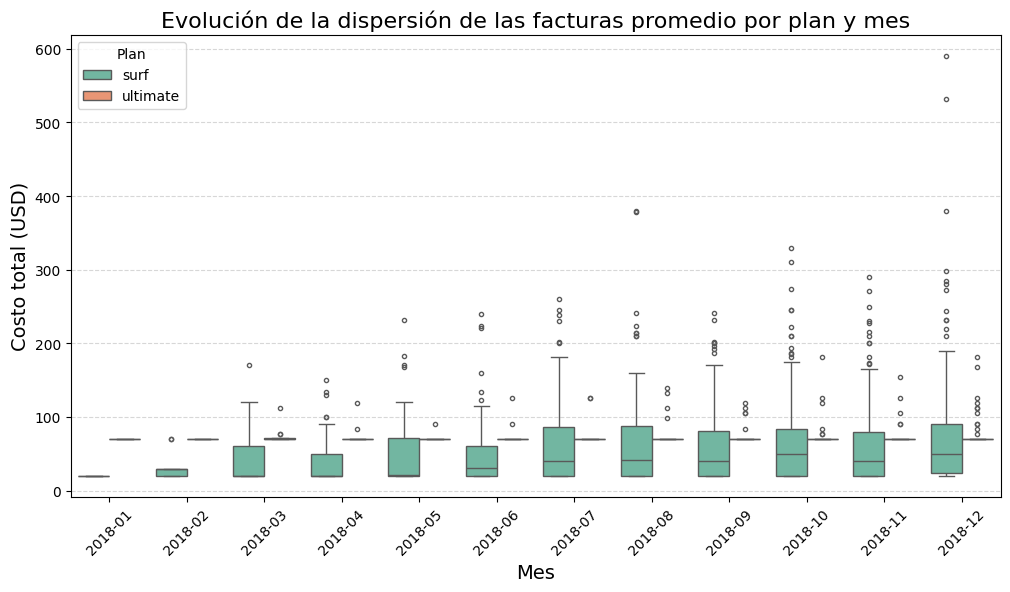

In [80]:
# Trazamos un diagrama de caja para visualizar la distribución de los tickets/facturas promedio al mes

# Gráfica de caja y bigote
plt.figure(figsize=(12, 6))

# Dibujamos el boxplot agrupado
sns.boxplot(
    data=datos_usuarios_mes,
    x='mes_str',
    y='costo_total',
    hue='plan',
    palette='Set2',       # Una paleta de colores suave para diferenciar bien las cajas
    fliersize=3           # Tamaño de los puntos atípicos
)

plt.title('Evolución de la dispersión de las facturas promedio por plan y mes', fontsize=16)
plt.xlabel('Mes', fontsize=14)
plt.ylabel('Costo total (USD)', fontsize=14)
plt.legend(title='Plan')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

In [81]:
# Borramos las columnas adicionales que ya no ocuparemos
datos_usuarios_mes = datos_usuarios_mes.drop(columns=['plan_name', 'minutes_included', 'messages_included', 
                                                      'mb_per_month_included', 'usd_monthly_pay', 'usd_per_minute', 
                                                      'usd_per_message', 'usd_per_gb', 'costo_minutos_adicionales', 'costo_mensajes_adicionales', 'costo_gb_adicionales'])
#datos_usuarios_mes.head()

Estas últimas gráficas nos confirman las observaciones anteriores. Tenemos una mayor dispesión del costo de la factura promedio en el plan surf respecto al plan ultimate. También tenemos más valores atípicos en el plan surf. Ante esto tenemos 2 observaciones clave:
1) Plan surf. Los usuarios están gastando más de los que su plan les proporciona, lo que podría indicar que el plan surf no satisface completamente las necesidades de sus usuarios, lo que podría ser un punto a considerar para la empresa al momento de ajustar sus planes y estrategias de marketing. También podría deberse a una falta de información o comprensión por parte de los usuarios del plan surf sobre las condiciones de su plan, lo que podría llevar a un uso excesivo y, por ende, a cargos adicionales. Esto podría ser un área de oportunidad para la empresa en términos de educación al cliente y comunicación clara sobre los límites y costos asociados con el plan surf.
2) Plan ultimate. Aunque el plan ultimate parece ser más adecuado para sus usuarios, también hay algunos usuarios que consumen menos datos de los que su plan proporciona, lo que podría indicar que algunos usuarios del plan ultimate no están aprovechando completamente su plan. Esto podría ser un punto a considerar para la empresa al momento de ajustar sus planes y estrategias de marketing, para incentivar a los usuarios del plan ultimate a aprovechar completamente su plan. Esto podría ser un área de oportunidad para la empresa en términos de educación al cliente y comunicación clara sobre los beneficios y características del plan ultimate para incentivar a los usuarios a aprovechar completamente su plan. Aquí también es importante verificar las ventajas adicionales por las cuales los clientes adquieren un plan ultimate, ya que podrían estar adquiriendo este plan por beneficios adicionales que no se reflejan en el análisis de los datos, como una mejor atención al cliente, acceso a promociones exclusivas, entre otros beneficios que podrían justificar la elección del plan ultimate por parte de algunos usuarios pese a no aprovechar completamente su plan en términos de consumo de datos.

## Prueba las hipótesis estadísticas

Ahora se probará la hipótesis de que son diferentes los ingresos promedio procedentes de los usuarios de los planes de llamada Ultimate y Surf. Para ello se usará una prueba de dos colas, de esta forma:
1. Se establecerán las hipóstesis nula y alternativa
    - Hipótesis nula ($H_0$): No hay diferencia entre los ingresos promedio de ambos planes
    - Hipótesis alternativa ($H_a$): Hay una diferencia entre los ingresos promedio de ambos planes.
2. Se establecerá un nivel de significancia, se usará un nivel de significancia del 5% (0.05).
3. Se usará una prueba de dos colas T de student por medio de la función <code>ttest_ind</code> de stats de scipy

[Elabora las hipótesis nula y alternativa, escoge la prueba estadística, determina el valor alfa.]

In [82]:
# Prueba las hipótesis
from scipy import stats as st

# Nivel de significacia
alpha = 0.05

# Extraemos los costos por plan
costos_surf = datos_usuarios_mes[datos_usuarios_mes['plan'] == 'surf']
costos_ultimate = datos_usuarios_mes[datos_usuarios_mes['plan'] == 'ultimate']

# Test t de student
resultados = st.ttest_ind(
    costos_surf['costo_total'],
    costos_ultimate['costo_total'],
    equal_var=False                     # Consideramos distribuciones con propiedades distintas
)

print('valor p:', resultados.pvalue)

if resultados.pvalue < alpha:
    print('Se rechaza la hipótesis nula: ' \
    '\nHay una diferencia significativa en los ingresos promedio de ambos planes.')
else:
    print('No se puede rechazar la hipótesis nula: ' \
    '\nNo hay evidencia suficiente para decir que los ingresos promedio son distintos.')

valor p: 3.170390548113711e-15
Se rechaza la hipótesis nula: 
Hay una diferencia significativa en los ingresos promedio de ambos planes.


Aunque la prueba T de Welch nos indica si el ingreso promedio es estadísticamente distinto, la alta varianza y la asimetría positiva en el plan Surf nos revela una dinámica de negocio dual: el plan Ultimate garantiza un ingreso fijo y predecible, mientras que la rentabilidad del plan Surf depende fuertemente de una 'cola larga' de usuarios que incurren en penalizaciones masivas por excedentes de datos.

Recordemos el resumen estadístico de los ingresos por plan

In [83]:
estadisticas_globales_cargos

,plan,usuarios,media,desv_est,varianza,minimo,q25,mediana,q75,maximo
0,surf,1573,60.71,55.39,3067.84,20.0,20.0,40.36,80.36,590.37
1,ultimate,720,72.31,11.40,129.85,70.0,70.0,70.00,70.00,182.00


Podemos ver una media y desviación estandar distinta para ambos planes. Probemos que ultimate efectivamente genera más ingresos.
- $H_0$: Ultimate no genera más ingresos que Surf.
- $H_a$: Ultimate genera más ingresos que Surf.

In [84]:
# Promedios observados
media_ultimate = estadisticas_globales_cargos.loc[estadisticas_globales_cargos['plan'] == 'ultimate', 'media'].values[0]
media_surf = estadisticas_globales_cargos.loc[estadisticas_globales_cargos['plan'] == 'surf', 'media'].values[0]

# Ejecutamos la prueba de una cola
resultados = st.ttest_ind(
    costos_ultimate['costo_total'], 
    costos_surf['costo_total'], 
    equal_var=False, 
    alternative='greater'
)

print(f'Valor p: {resultados.pvalue:.4f}')

# 3. Lógica de decisión combinada
if (resultados.pvalue < alpha) and (media_ultimate > media_surf):
    print("Conclusión: Se rechaza H0. Tenemos evidencia estadística suficiente para")
    print("afirmar que el plan Ultimate genera más ingresos promedio que el plan Surf.")
else:
    print("Conclusión: No se puede rechazar H0. No hay evidencia de que Ultimate genere más ingresos.")

Valor p: 0.0000
Conclusión: Se rechaza H0. Tenemos evidencia estadística suficiente para
afirmar que el plan Ultimate genera más ingresos promedio que el plan Surf.


Con esto podemos ver que el plan ultimate genera más ingresos que el plan surf.

Ahora probaremos la hipótesis de que el ingreso promedio de los usuarios del área NY-NJ (New York-Newark-Jersey City, NY-NJ-PA MSA) es diferente al de los usuarios de otras regiones.
Las hipótesis son:
- $H_0$: No hay diferencias entre el ingreso promedio de los usuarios del área NY-NJ y el ingreso promedio de los usuarios de otras regiones.
- $H_a$: Hay diferencias entre el ingreso promedio de los usuarios del área NY-NJ y el ingreso promedio de los usuarios de otras regiones.

Para ello se usará una prueba de dos colas con una significancia del 5% (0.05) y se usará una prueba T de Welch por medio de la función <code>ttest_ind</code> de stats de scipy.

In [85]:
# Ciudades únicas en el DataFrame de usuarios
ciudades_unicas = usuarios['city'].unique()
print("Ciudades únicas en el DataFrame de usuarios:")
print(ciudades_unicas)

Ciudades únicas en el DataFrame de usuarios:
['Atlanta-Sandy Springs-Roswell, GA MSA' 'Seattle-Tacoma-Bellevue, WA MSA'
 'Las Vegas-Henderson-Paradise, NV MSA' 'Tulsa, OK MSA'
 'Dallas-Fort Worth-Arlington, TX MSA'
 'San Francisco-Oakland-Berkeley, CA MSA' 'Grand Rapids-Kentwood, MI MSA'
 'Orlando-Kissimmee-Sanford, FL MSA'
 'San Jose-Sunnyvale-Santa Clara, CA MSA' 'Cleveland-Elyria, OH MSA'
 'Chicago-Naperville-Elgin, IL-IN-WI MSA' 'Knoxville, TN MSA'
 'New York-Newark-Jersey City, NY-NJ-PA MSA' 'Pittsburgh, PA MSA'
 'Fresno, CA MSA' 'Washington-Arlington-Alexandria, DC-VA-MD-WV MSA'
 'Indianapolis-Carmel-Anderson, IN MSA' 'Jacksonville, FL MSA'
 'Los Angeles-Long Beach-Anaheim, CA MSA'
 'Omaha-Council Bluffs, NE-IA MSA'
 'Houston-The Woodlands-Sugar Land, TX MSA'
 'Philadelphia-Camden-Wilmington, PA-NJ-DE-MD MSA'
 'Tampa-St. Petersburg-Clearwater, FL MSA' 'Birmingham-Hoover, AL MSA'
 'Oklahoma City, OK MSA' 'Charlotte-Concord-Gastonia, NC-SC MSA'
 'Denver-Aurora-Lakewood, CO MSA'
 'N

In [86]:
# Ciudades de New York-Newark-Jersey City, NY-NJ-PA MSA'
usuarios_ny_nj = usuarios[usuarios['city'] == 'New York-Newark-Jersey City, NY-NJ-PA MSA']
print("\nUsuarios de la ciudad de New York-Newark-Jersey City, NY-NJ-PA MSA:")
usuarios_ny_nj.head()


Usuarios de la ciudad de New York-Newark-Jersey City, NY-NJ-PA MSA:


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,años_registro
14,1014,Edmundo,Simon,61,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-11-25,surf,NaT,7.350685
22,1022,Bo,Snow,73,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-04-20,surf,2018-09-07,7.950685
24,1024,Yuki,Tyson,74,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-08-21,surf,NaT,7.613699
27,1027,Georgeanna,Cardenas,38,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-06-26,surf,NaT,7.767123
31,1031,Lane,Martin,52,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-07-15,ultimate,NaT,7.715068


Ahora haremos un merge sobre datos_usuarios_mes y el DataFrame de usuarios para agregar la información de la ciudad de cada usuario. Después se segmentarán los usuarios del área NY-NJ (New York-Newark-Jersey City, NY-NJ-PA MSA) y se realizará la prueba de hipótesis para comparar el ingreso promedio de los usuarios de esta área con el ingreso promedio de los usuarios de otras regiones.

In [87]:
datos_usuarios_mes = datos_usuarios_mes.merge(usuarios[['user_id', 'city']], on='user_id', how='left')
datos_usuarios_mes.head()

,user_id,mes,llamadas_totales,minutos_totales,mensajes_totales,volumen_total_mb,volumen_total_gb,plan,usd_plan_mes,cargos_adicionales,costo_total,mes_str,city
0,1042,2018-01,18,114,0.0,1854.93,2,surf,20,0.0,20.0,2018-01,"Philadelphia-Camden-Wilmington, PA-NJ-DE-MD MSA"
1,1185,2018-01,23,181,0.0,6812.77,7,ultimate,70,0.0,70.0,2018-01,"Louisville/Jefferson County, KY-IN MSA"
2,1077,2018-01,42,290,37.0,10635.64,11,ultimate,70,0.0,70.0,2018-01,"Charlotte-Concord-Gastonia, NC-SC MSA"
3,1362,2018-01,42,292,21.0,7894.79,8,surf,20,0.0,20.0,2018-01,"Denver-Aurora-Lakewood, CO MSA"
4,1214,2018-01,5,16,2.0,1315.35,2,ultimate,70,0.0,70.0,2018-01,"San Francisco-Oakland-Berkeley, CA MSA"


In [88]:
# Creamos una columan adicional para clasificar los usuarios de la región NY-NJ y todos los demás
datos_usuarios_mes['region'] = np.where(
    datos_usuarios_mes['city'] == 'New York-Newark-Jersey City, NY-NJ-PA MSA',
    'NY-NJ',
    'Otros'
)

datos_usuarios_mes.head()

,user_id,mes,llamadas_totales,minutos_totales,mensajes_totales,volumen_total_mb,volumen_total_gb,plan,usd_plan_mes,cargos_adicionales,costo_total,mes_str,city,region
0,1042,2018-01,18,114,0.0,1854.93,2,surf,20,0.0,20.0,2018-01,"Philadelphia-Camden-Wilmington, PA-NJ-DE-MD MSA",Otros
1,1185,2018-01,23,181,0.0,6812.77,7,ultimate,70,0.0,70.0,2018-01,"Louisville/Jefferson County, KY-IN MSA",Otros
2,1077,2018-01,42,290,37.0,10635.64,11,ultimate,70,0.0,70.0,2018-01,"Charlotte-Concord-Gastonia, NC-SC MSA",Otros
3,1362,2018-01,42,292,21.0,7894.79,8,surf,20,0.0,20.0,2018-01,"Denver-Aurora-Lakewood, CO MSA",Otros
4,1214,2018-01,5,16,2.0,1315.35,2,ultimate,70,0.0,70.0,2018-01,"San Francisco-Oakland-Berkeley, CA MSA",Otros


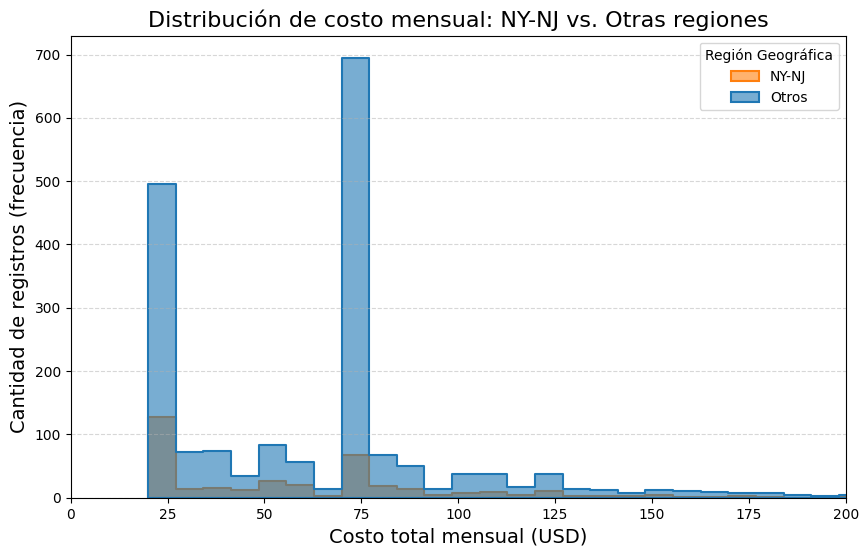

In [89]:
plt.figure(figsize=(10, 6))
datos_plan.plot(kind='bar', stacked=True, ax=axes[i], alpha=0.9)

# Usamos la nueva columna 'region' para el hue
sns.histplot(
    data=datos_usuarios_mes,
    x='costo_total',
    hue='region',
    bins=80,
    alpha=0.6,
    element='step',
    linewidth=1.5,
    #palette=colores_okabe
)

plt.title('Distribución de costo mensual: NY-NJ vs. Otras regiones', fontsize=16)
plt.xlabel('Costo total mensual (USD)', fontsize=14)
plt.ylabel('Cantidad de registros (frecuencia)', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xlim(0, 200)

# Etiquetas para la leyenda
plt.legend(title='Región Geográfica', labels=['NY-NJ', 'Otros'])

plt.show()

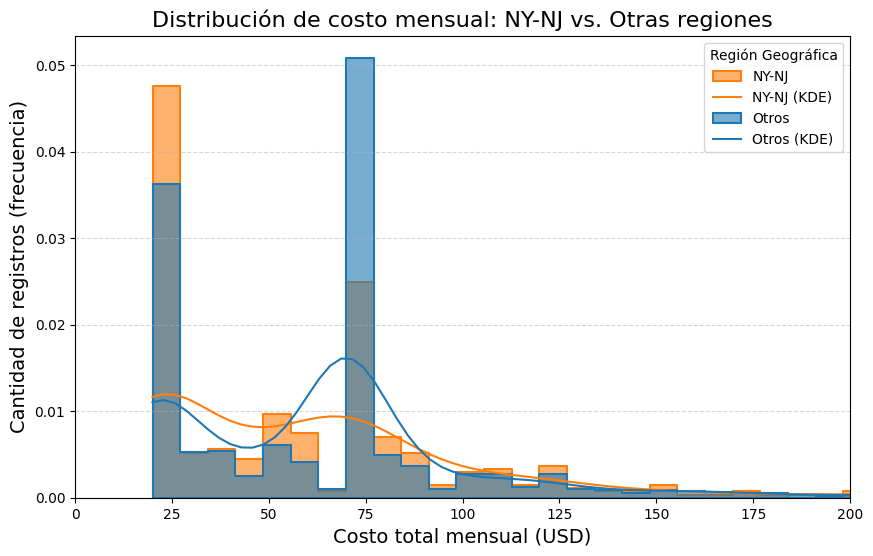

In [90]:
plt.figure(figsize=(10, 6))

datos_plan.plot(kind='bar', stacked=True, ax=axes[i], alpha=0.9)

# Usamos la nueva columna 'region' para el hue
sns.histplot(
    data=datos_usuarios_mes,
    x='costo_total',
    hue='region',
    bins=80,
    alpha=0.6,
    element='step',
    linewidth=1.5,
    kde=True,
    stat='density',
    common_norm=False)

plt.title('Distribución de costo mensual: NY-NJ vs. Otras regiones', fontsize=16)
plt.xlabel('Costo total mensual (USD)', fontsize=14)
plt.ylabel('Cantidad de registros (frecuencia)', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xlim(0, 200)

# Etiquetas para la leyenda
plt.legend(title='Región Geográfica', labels=['NY-NJ', 'NY-NJ (KDE)','Otros', 'Otros (KDE)'])

plt.show()

In [91]:
# Prueba estadística de dos colas usando la prueba T Welch para comparar los costos totales entre la región NY-NJ y las otras regiones

# Población de NY-NJ
poblacion_ny_nj = datos_usuarios_mes[datos_usuarios_mes['region'] == 'NY-NJ']
poblacion_adicional = datos_usuarios_mes[datos_usuarios_mes['region'] == "Otros"]

# Nivel de significancia
alpha = 0.05

resultados = st.ttest_ind(poblacion_ny_nj['costo_total'], poblacion_adicional['costo_total'], equal_var=False)

print(f'P valor: {resultados.pvalue:.4f}')

if resultados.pvalue < alpha:
    print('Se rechaza la hipótesis nula: ' \
    '\nhay una diferencia significativa en los costos totales entre la región NY-NJ y las otras regiones.')
else:
    print('No se rechaza la hipótesis nula: ' \
    '\nno hay evidencia suficiente para afirmar una diferencia significativa en los costos totales entre la región NY-NJ y las otras regiones.')

P valor: 0.0335
Se rechaza la hipótesis nula: 
hay una diferencia significativa en los costos totales entre la región NY-NJ y las otras regiones.


In [92]:
# Prueba con Mann-Whitney U (prueba no paramétrica) para comparar los costos totales entre la región NY-NJ y las otras regiones
resultados = st.mannwhitneyu(poblacion_ny_nj['costo_total'], poblacion_adicional['costo_total'], alternative='two-sided')

print(f'P valor: {resultados.pvalue:.4f}')

if resultados.pvalue < alpha:
    print('Se rechaza la hipótesis nula: ' \
    '\nhay una diferencia significativa en los costos totales entre la región NY-NJ y las otras regiones.')
else:
    print('No se rechaza la hipótesis nula: ' \
    '\nno hay evidencia suficiente para afirmar una diferencia significativa en los costos totales entre la región NY-NJ y las otras regiones.')

P valor: 0.0039
Se rechaza la hipótesis nula: 
hay una diferencia significativa en los costos totales entre la región NY-NJ y las otras regiones.


Con ambas prueba estadística rechazando la hipótesis nula, se concluye que hay diferencias estadísticamente significativas entre los ingresos de los usuarios de la region de NY-NJ y todas las demás regiones, esto pese a la aparente semejanza en las gráficas. Esto justifica una estretegia comercial diferente entre, por lo menos, estas dos regiones.

Ahora sabemos que hay diferencia estadística, confirmemos cuál promedio de ingresos es mayor por medio de otra prueba estadística de una cola, ahora consideremos:

- $H_0$: El ingreso promedio nacional es mayor o igual al promedio de la zona NY-NJ($\mu _{Ny-NJ} \leq \mu _{nacional} $)
- $H_a$: El ingreso promedio nacional es menor al ingreso promedio de la zona NY-NJ ($\mu _{nacional} < \mu _{Ny-NJ}$)

Usemos una significancia de 0.05 y ambas test, t de Welch y Mann-Whitney. Este último test se usará porque tenemos distribuciones bimodales por los dos planes que se manejan en la empresa, entonces verificaremos la probabilidad de que al tomar un usuario al azar de la región de NY-NJ, $X$, y otro del resto de las regiones, $Y$, se cumpla que el valor de $X > Y$

In [93]:
# Preparación de los grupos
ingresos_ny_nj = datos_usuarios_mes[datos_usuarios_mes['region'] == 'NY-NJ']['costo_total']
ingresos_otros = datos_usuarios_mes[datos_usuarios_mes['region'] == 'Otros']['costo_total']

# Medias observadas
print(f"Media NY-NJ: ${ingresos_ny_nj.mean():.2f}")
print(f"Media Otras: ${ingresos_otros.mean():.2f}")

# Prueba T de Welch de una cola
# alternative='greater' comprueba si el primer grupo es mayor que el segundo
resultados_sup = st.ttest_ind(ingresos_ny_nj, ingresos_otros, equal_var=False, alternative='greater')

# Prueba de Mann-Whitney de una cola
resultados_mw_sup = st.mannwhitneyu(ingresos_ny_nj, ingresos_otros, alternative='greater')

print(f"\nValor p (T-Welch Superioridad): {resultados_sup.pvalue:.4f}")
print(f"Valor p (Mann-Whitney Superioridad): {resultados_mw_sup.pvalue:.4f}")

if (resultados_mw_sup.pvalue < 0.05) and (ingresos_ny_nj.mean() > ingresos_otros.mean()):
    print("\nSe rechaza la hipótesis nula: " \
    "\nSe confirma que el ingreso en NY-NJ es estadísticamente superior.")
else:
    print("\nNo se puede rechazar la hipótesis nula:" \
    "\nNo hay evidencia suficiente para afirmar superioridad.")

Media NY-NJ: $59.92
Media Otras: $65.22

Valor p (T-Welch Superioridad): 0.9832
Valor p (Mann-Whitney Superioridad): 0.9980

No se puede rechazar la hipótesis nula:
No hay evidencia suficiente para afirmar superioridad.


## Conclusión general

<section style="margin-top: 15px;">
<p><strong>1. Preparación de datos y reglas de facturación</strong></p>
    <p>El análisis se fundamentó en la aplicación estricta de las reglas de negocio de Megaline, traduciendo el comportamiento físico de los usuarios en unidades facturables. Se destaca el impacto de las <b>reglas de redondeo</b>: las llamadas individuales se redondearon al minuto superior y el tráfico de internet se consolidó mensualmente para redondearse al Gigabyte superior. Este preprocesamiento fue vital para modelar correctamente los ingresos, convirtiendo el consumo nominal en un sistema de cobro por escalones.</p>
</section>

<section style="margin-top: 15px;">
    <p><strong>2. Resultados cuantitativos y pruebas estadísticas</strong></p>
    <p>Las pruebas de hipótesis revelaron diferencias estructurales en el flujo de ingresos de ambos planes:</p>
    <ul>
        <li><b>Plan Ultimate:</b> Se identificó como el motor de ingresos más estable, con un promedio mensual de aprox. <b>$72.31 USD</b> y varianza mínima. La prueba T confirmó su mayor rentabilidad promedio con un nivel de confianza del 95% (<i>p < 0.05</i>).</li>
        <li><b>Plan Surf:</b> Presentó una <b>asimetría positiva (cola larga)</b> con un promedio de aprox. <b>\$60.77 USD</b>. Su rentabilidad depende críticamente de las penalizaciones por excedentes, especialmente en datos.</li>
        <li><b>Diferenciación Regional:</b> Se comprobó de forma robusta que los usuarios de la región <b>NY-NJ</b> poseen un comportamiento de gasto sistemáticamente distinto al resto del país (<i>p = 0.0040</i>), lo que valida la segmentación geográfica.</li>
    </ul>
</section>

<section style="margin-top: 15px;">
    <p><strong>3. Recomendaciones de negocio</strong></p>
    <p>Basado en la evidencia estadística, se proponen las siguientes acciones estratégicas:</p>
    <ul>
        <li><b>Estrategia de cambio de plan:</b> Dirigir campañas de migración al plan Ultimate para los usuarios de Surf que incurren recurrentemente en excedentes. Esto garantiza ingresos fijos para la empresa y elimina la fricción por cobros inesperados para el cliente.</li>
        <li><b>Análisis de mercado en NY-NJ:</b> Investigar las causas del menor ingreso promedio en la zona metropolitana de NY-NJ. Podría deberse a una mayor disponibilidad de redes Wi-Fi públicas o a un perfil de usuario más consciente de sus límites, lo que sugiere que las promociones de «paquetes adicionales» podrían no ser tan efectivas en esta zona.</li>
        <li><b>Rediseño de oferta:</b> Evaluar la creación de un plan intermedio (ej. 22 GB), dado que una gran masa de usuarios de Surf se encuentra atrapada en un régimen de penalización constante al superar los 15 GB, pero sin llegar a los 30 GB de Ultimate.</li>
    </ul>
</section>